# **Microproyecto1 — Generación de Música con LSTM**
Equipo: 2

## **Estudiantes**
- Juan Sebastián Casas Castillo
- Leandro Jiménez Puerta
- Juan Camilo Martinez Velez
- Javier Andres Marin Gallon
- Isabella Del Pilar Camargo Salazar

## **Contenido**
- [0. Configuración](#sec0)
  - [0.1 Entorno (Colab / local)](#sec01)
  - [0.2 Imports y variables globales](#sec02)
- [1. Lectura de datos](#sec1)
  - [1.1 Carga de archivos MIDI](#sec11)
  - [1.2 Train / Val / Test split](#sec12)
- [2. Análisis exploratorio (EDA)](#sec2)
  - [2.1 Número de canciones](#sec21)
  - [2.2 Vista rápida de los datos](#sec22)
  - [2.3 Distribución de atributos](#sec23)
- [3. Procesamiento de datos](#sec3)
  - [3.1 Codificación de pitch](#sec31)
  - [3.2 Normalización — step y duration](#sec32)
  - [3.3 Transformación completa](#sec33)
  - [3.4 Augmentación por transposición](#sec34)
  - [3.5 Secuencias de entrenamiento](#sec35)
- [4. DataLoader](#sec4)
  - [4.1 Splits y transformación sin leakage](#sec41)
  - [4.2 Clase MusicDataLoader](#sec42)
- [5. Experimentación previa](#sec5_exp)
- [6. Arquitectura Dual LSTM](#sec6)
  - [6.1 Diagrama arquitectura seleccionada](#sec61)
  - [6.2 Hiperparámetros y vocabularios](#sec62)
  - [6.3 Modelos: NoteNet1 y NoteNet2](#sec63)
- [7. Entrenamiento](#sec7)
  - [7.1 Funciones de pérdida y pesos](#sec71)
  - [7.2 Métricas: Perplexity](#sec72)
  - [7.3 Hiperparámetros de entrenamiento](#sec73)
  - [7.4 Proceso de entrenamiento y validación](#sec74)
  - [7.5 Guardar modelo](#sec75)
- [8. Evaluación — Curvas de pérdida](#sec8)
  - [8.1 Curvas de pérdida — NoteNet1](#sec81)
  - [8.2 Curvas de pérdida — NoteNet2](#sec82)
- [9. Cargar modelo](#sec9)
  - [9.1 Cargar checkpoint](#sec91)
- [10. Evaluación con datos reales (Test)](#sec10_eval)
  - [10.1 Selección de semilla](#sec10_1)
  - [10.2 Función de generación baseline y comparación](#sec10_2)
  - [10.3 Ejecución — generación baseline](#sec10_3)
- [11. Generación con restricciones musicales](#sec11)
  - [11.0 Constantes y funciones auxiliares](#sec11_0)
  - [11.1 Distribución de intervalos del corpus](#sec11_1)
  - [11.2 Restricciones musicales suaves](#sec11_2)
  - [11.3 Función de generación con restricciones](#sec11_3)
  - [11.4 Ejecución y comparación con datos reales](#sec11_4)
  - [11.5 Conclusiones](#sec11_5)
- [12. Generación desde cero](#sec12)
  - [12.1 Notas de inicio](#sec12_1)
  - [12.2 Generación y exportación a MIDI](#sec12_2)
- [13. Escuchar canciones generadas](#sec13)


In [ ]:
# En esta parte se define el Path de los datos.
DATA_PATH = f'./data/music_artist/beeth'

<a id='sec0'></a>
# 0. Configuración

<a id='sec01'></a>
## 0.1 Entorno (Colab / local)

Monta Google Drive e instala `pretty_midi` si se ejecuta en Colab. Cambiar `COLAB = False` para entorno local.

In [1]:
# False → local  |  True → Google Colab
COLAB = False
TRAIN = False

if COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    !pip install pretty_midi


<a id='sec02'></a>
## 0.2 Imports y variables globales

Importaciones estándar y configuración inicial: semilla aleatoria, artista objetivo y flags de control.

In [2]:
import math
import os
import time
import pretty_midi
import pygame
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from collections import defaultdict, Counter
from IPython.display import Audio, display
from scipy.spatial.distance import jensenshannon

import random
import torch
import torch.nn as nn
import torch.nn.functional as F

/opt/anaconda3/envs/master/lib/python3.11/site-packages/pygame/pkgdata.py:25: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import resource_stream, resource_exists


pygame 2.6.1 (SDL 2.28.4, Python 3.11.13)
Hello from the pygame community. https://www.pygame.org/contribute.html


In [ ]:
SEED = 422

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

EDA    = True
artist = 'beeth'
TEMP = 1.2

<a id='sec1'></a>
# 1. Lectura de datos

<a id='sec11'></a>
## 1.1 Carga de archivos MIDI

Se leen los archivos `.mid` del *Beethoven* , extrae las notas del instrumento piano (`pitch`, `step`, `duration`, `velocity`) y construye un DataFrame unificado.

In [ ]:
if COLAB:
    DATA_PATH = f'/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/data/music_artist/{artist}'
else:
    DATA_PATH = DATA_PATH
TARGET_INS = 'Acoustic Grand Piano'

midi_files = sorted([os.path.join(DATA_PATH, f)
                     for f in os.listdir(DATA_PATH) if f.endswith('.mid')])
print(f'Archivos MIDI encontrados: {len(midi_files)}')

def extract_notes(inst):
    rows, prev_start = [], None
    for note in sorted(inst.notes, key=lambda x: x.start):
        dur  = note.end - note.start
        step = note.start - prev_start if prev_start is not None else 0.0
        rows.append({
            'pitch':    note.pitch,
            'duration': dur,
            'step':     step,
            'velocity': note.velocity,
        })
        prev_start = note.start
    return rows

records = []
for sid, fpath in enumerate(midi_files):
    pm    = pretty_midi.PrettyMIDI(fpath)
    base  = os.path.basename(fpath)
    piano = [inst for inst in pm.instruments
             if pretty_midi.program_to_instrument_name(inst.program) == TARGET_INS
             and len(inst.notes) >= 10]
    for hi, inst in enumerate(piano):
        for row in extract_notes(inst):
            row.update({'song_id': sid, 'song_name': base, 'n_pista': hi + 1})
            records.append(row)

df = pd.DataFrame(records)[['song_id','song_name','n_pista','pitch','duration','step','velocity']]
print(f'Canciones con piano: {df["song_id"].nunique()}  |  Notas totales: {len(df):,}')


Archivos MIDI encontrados: 29
Canciones con piano: 23  |  Notas totales: 84,785


<a id='sec12'></a>
## 1.2 Train / Val / Test split

Se separan 3 canciones para test, el 10 % del resto para validación y el resto para entrenamiento. El split se hace a nivel de canción completa para evitar leakage.

In [6]:
all_songs  = df['song_name'].unique()
test_songs = np.random.choice(all_songs, size=3, replace=False)
remaining  = [s for s in all_songs if s not in test_songs]
n_val      = max(1, int(np.ceil(0.1 * len(remaining))))
val_songs  = np.random.choice(remaining, size=n_val, replace=False)
train_songs = [s for s in remaining if s not in val_songs]

df_test  = df[ df['song_name'].isin(test_songs)].reset_index(drop=True)
df_val   = df[ df['song_name'].isin(val_songs)].reset_index(drop=True)
df_train = df[ df['song_name'].isin(train_songs)].reset_index(drop=True)

print(f'Test  songs : {sorted(test_songs)}')
print(f'Val   songs : {sorted(val_songs)}')
print(f'Train songs : {len(train_songs)}  |  Val: {len(val_songs)}  |  Test: {len(test_songs)}')
print(f'Train notes : {len(df_train):,}  |  Val: {len(df_val):,}  |  Test: {len(df_test):,}')

Test  songs : ['beethoven_les_adieux_2.mid', 'beethoven_opus22_2.mid', 'elise.mid']
Val   songs : ['beethoven_opus10_1.mid', 'beethoven_opus22_1.mid']
Train songs : 18  |  Val: 2  |  Test: 3
Train notes : 72,622  |  Val: 8,063  |  Test: 4,100


<a id='sec2'></a>
# 2. Análisis exploratorio (EDA)

Todas las visualizaciones de esta sección se ejecutan sólo si `EDA = True`.

<a id='sec21'></a>
## 2.1 Número de canciones

Cuántos archivos MIDI hay en el split de train y cuántas notas contiene cada uno.

In [7]:
if EDA:
    resumen = (df_train.groupby(['song_id', 'song_name'])['pitch'].count().rename('n_notas').reset_index())
    print(f'Total de canciones de Beethoven (train): {len(resumen)}\n')
    display(resumen)

Total de canciones de Beethoven (train): 18



,song_id,song_name,n_notas
0,0,appass_1.mid,6377
1,1,appass_2.mid,1981
2,2,appass_3.mid,7223
3,3,beethoven_hammerklavier_1.mid,8290
4,4,beethoven_hammerklavier_2.mid,1887
5,5,beethoven_hammerklavier_3.mid,5190
6,6,beethoven_hammerklavier_4.mid,8008
7,7,beethoven_les_adieux_1.mid,3308
8,9,beethoven_les_adieux_3.mid,5331
9,11,beethoven_opus10_2.mid,1616


<a id='sec22'></a>
## 2.2 Vista rápida de los datos

Primeras filas y estadísticas descriptivas del DataFrame de entrenamiento.

In [8]:
if EDA:
    display(df_train.head(5))
    display(df_train.describe().round(3))

,song_id,song_name,n_pista,pitch,duration,step,velocity
0,0,appass_1.mid,1,60,0.518640,0.000000,35
1,0,appass_1.mid,1,56,0.136599,0.518640,31
2,0,appass_1.mid,1,53,1.669347,0.136599,28
3,0,appass_1.mid,1,56,0.477331,1.669347,35
4,0,appass_1.mid,1,60,0.107427,0.477331,30


,song_id,n_pista,pitch,duration,step,velocity
count,72622.000,72622.000,72622.000,72622.000,72622.000,72622.000
mean,8.707,1.490,63.563,0.283,0.194,52.608
std,7.083,0.506,13.975,0.423,0.458,16.487
min,0.000,1.000,24.000,0.007,0.000,12.000
25%,3.000,1.000,54.000,0.096,0.000,40.000
50%,6.000,1.000,64.000,0.136,0.107,51.000
75%,16.000,2.000,74.000,0.297,0.208,64.000
max,22.000,3.000,101.000,13.944,75.246,125.000


<a id='sec23'></a>
## 2.3 Distribución de atributos

Histogramas de `pitch`, `step` y `velocity` por canción y por atributo.

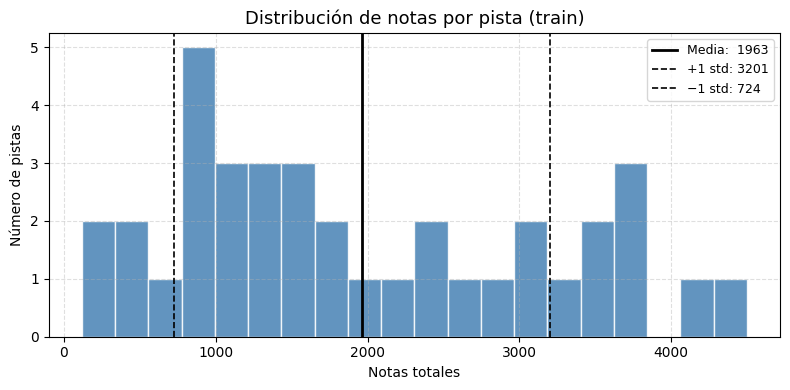

In [9]:
if EDA:
    # Notas por pista
    notas_por_pista = (df_train.groupby(['song_id', 'song_name', 'n_pista'])['pitch'].count().rename('n_notas').reset_index())
    media = notas_por_pista['n_notas'].mean()
    std   = notas_por_pista['n_notas'].std()

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(notas_por_pista['n_notas'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
    ax.axvline(media,       color='black', linewidth=2,   linestyle='-',  label=f'Media:  {media:.0f}')
    ax.axvline(media + std, color='black', linewidth=1.2, linestyle='--', label=f'+1 std: {media+std:.0f}')
    ax.axvline(media - std, color='black', linewidth=1.2, linestyle='--', label=f'−1 std: {media-std:.0f}')
    ax.set_title('Distribución de notas por pista (train)', fontsize=13)
    ax.set_xlabel('Notas totales')
    ax.set_ylabel('Número de pistas')
    ax.grid(True, linestyle='--', alpha=0.4)
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.show()


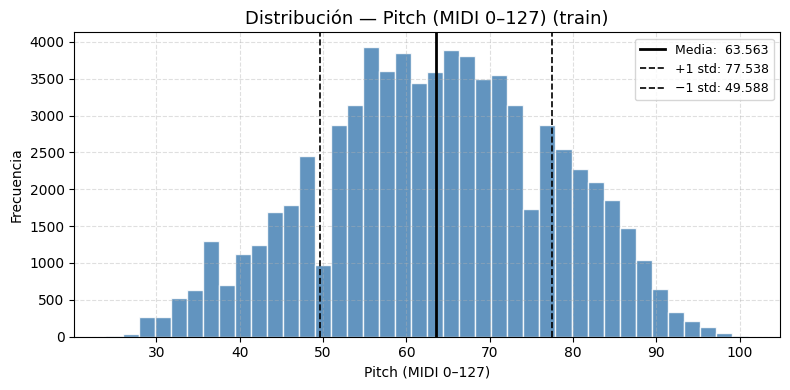

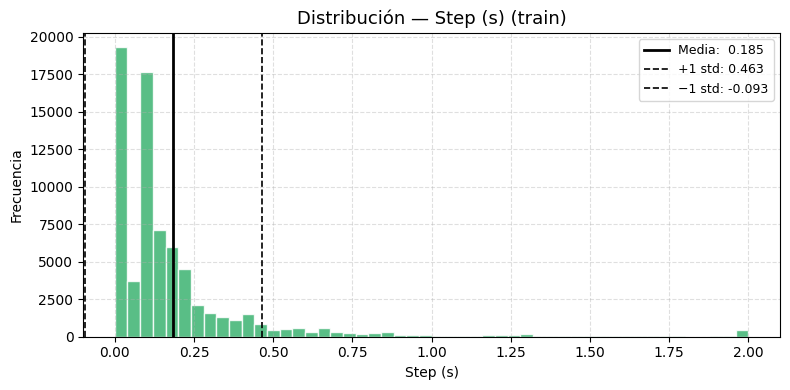

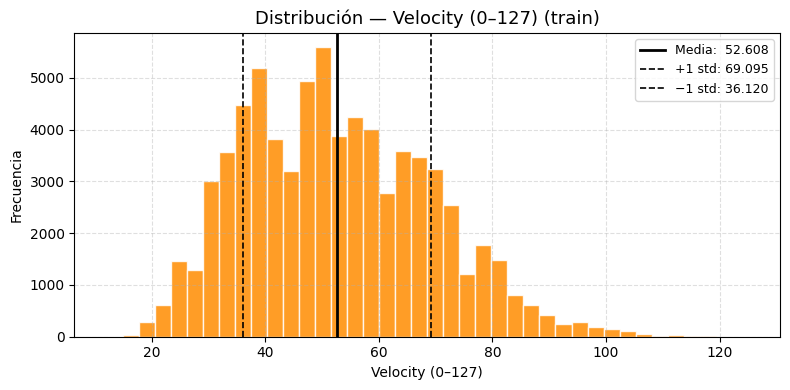

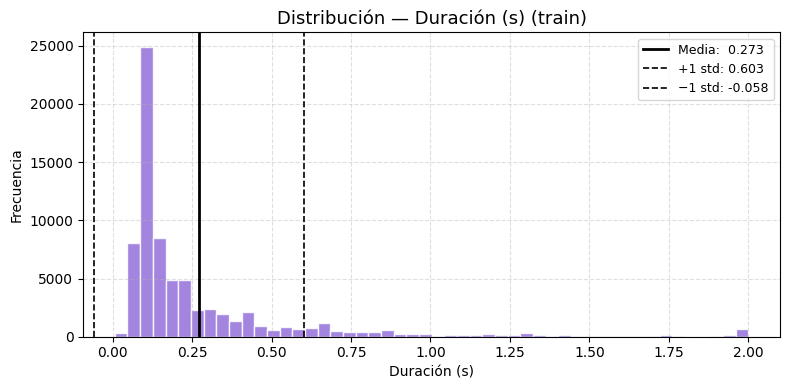

In [10]:
if EDA:
    atributos = [
        ('pitch',    None, 'Pitch (MIDI 0–127)',  'steelblue',  40),
        ('step',     2.0,  'Step (s)',            'mediumseagreen', 50),
        ('velocity', None, 'Velocity (0–127)',    'darkorange', 40),
        ('duration', 2.0,  'Duración (s)',        'mediumpurple', 50),
    ]

    for col, clip, titulo, color, bins in atributos:
        datos = df_train[col].clip(0, clip).dropna() if clip else df_train[col].dropna()
        media, std = datos.mean(), datos.std()

        fig, ax = plt.subplots(figsize=(8, 4))
        ax.hist(datos, bins=bins, color=color, edgecolor='white', alpha=0.85)

        ax.axvline(media,        color='black',  linewidth=2,   linestyle='-',  label=f'Media:  {media:.3f}')
        ax.axvline(media + std,  color='black',  linewidth=1.2, linestyle='--', label=f'+1 std: {media+std:.3f}')
        ax.axvline(media - std,  color='black',  linewidth=1.2, linestyle='--', label=f'−1 std: {media-std:.3f}')

        ax.set_title(f'Distribución — {titulo} (train)', fontsize=13)
        ax.set_xlabel(titulo)
        ax.set_ylabel('Frecuencia')
        ax.grid(True, linestyle='--', alpha=0.4)
        ax.legend(fontsize=9)

        plt.tight_layout()
        plt.show()

Se observa que las variables *pitch* y *velocity* presentan una distribución aproximadamente normal, con la mayoría de sus valores concentrados en la región central de sus rangos respectivos: alrededor de 63 para pitch y 52 para velocity. Por otro lado, las variables *step* y *duration* presentan una distribución fuertemente asimétrica hacia la izquierda, con la mayor parte de los datos entre 0 y 1 segundo, pero con valores atípicos considerablemente alejados de ese rango (hasta 14 s en duration y 75 s en step). Esta exploración fue determinante para definir el preprocesamiento aplicado a cada variable en la siguiente sección.

<a id='sec3'></a>
# 3. Procesamiento de datos

<a id='sec31'></a>
## 3.1 Codificación de pitch

El estándar MIDI define 128 alturas posibles para una nota musical. Sin embargo, representar el pitch directamente como una variable con 128 clases introduce un vocabulario innecesariamente grande que puede dificultar el aprendizaje. En su lugar, se descompone cada nota en dos variables independientes: *pitch class*, que indica la nota dentro de la octava (Do, Do\#, Re, Re\#, Mi, Fa, Fa\#, Sol, Sol\#, La, La\#, Si — 12 valores), y la *octave*, que indica su posición en el teclado (11 valores). Esta representación puede facilitar el aprendizaje, ya que predecir correctamente la nota y su octava de forma separada es un problema más manejable que clasificar entre 128 clases. Al momento de la generación, ambas variables se combinan para reconstruir el pitch MIDI completo mediante *pitch = octave * 12 + pitch_class* .

El pitch (0–127) se descompone en `pitch_class` (0–11) y `octave` (0–10). Se definen los vocabularios de cada variable discreta.

In [11]:
pitch_table = pd.DataFrame({
    'pitch':       range(128),
    'note_name':   [pretty_midi.note_number_to_name(p) for p in range(128)],
    'pitch_class': [p % 12        for p in range(128)],
    'octave':      [(p // 12) - 1 for p in range(128)],
    'octave_idx':  [p // 12       for p in range(128)],
})

PITCH_CLASS_VOCAB = 12
OCTAVE_VOCAB      = 11

print('Muestra de la tabla de codificación MIDI:')
display(pitch_table.iloc[[0, 12, 24, 36, 48, 60, 69, 72, 84, 96, 108, 127]])
print(f'\npitch_class vocab: {PITCH_CLASS_VOCAB}  |  octave vocab: {OCTAVE_VOCAB}')

Muestra de la tabla de codificación MIDI:


,pitch,note_name,pitch_class,octave,octave_idx
0,0,C-1,0,-1,0
12,12,C0,0,0,1
24,24,C1,0,1,2
36,36,C2,0,2,3
48,48,C3,0,3,4
60,60,C4,0,4,5
69,69,A4,9,4,5
72,72,C5,0,5,6
84,84,C6,0,6,7
96,96,C7,0,7,8



pitch_class vocab: 12  |  octave vocab: 11


<a id='sec32'></a>
## 3.2 Normalización — step y duration

Para las variables *step* y *duration*, que son continuas y pueden tener valores atípicos bastante grandes, se decidió transformarlas en variables categóricas usando 8 bins.

El proceso se realiza en dos pasos. Primero, se utiliza el percentil 98 (p98) para limitar los valores extremos, evitando que unos pocos outliers distorsionen la distribución. Luego, se aplica una transformación logarítmica para comprimir la escala y hacer la distribución más equilibrada.

Finalmente, sobre estos datos transformados, se definen los bordes de los bins (las líneas azules y moradas), de manera que cada uno contenga aproximadamente la misma cantidad de ejemplos. Esto permite que el modelo aprenda de forma más balanceada y estable.

Se calculan `N_BINS` bins equiprobables en escala log para `step` y `duration`. Para `velocity` se usa un valor fijo de **media = 51** en lugar de la distribución empírica.

In [12]:
N_BINS = 8


### 3.2.1 Step

Bins log-equiprobables sobre `step`. Se visualiza la distribución antes y después de la transformación.

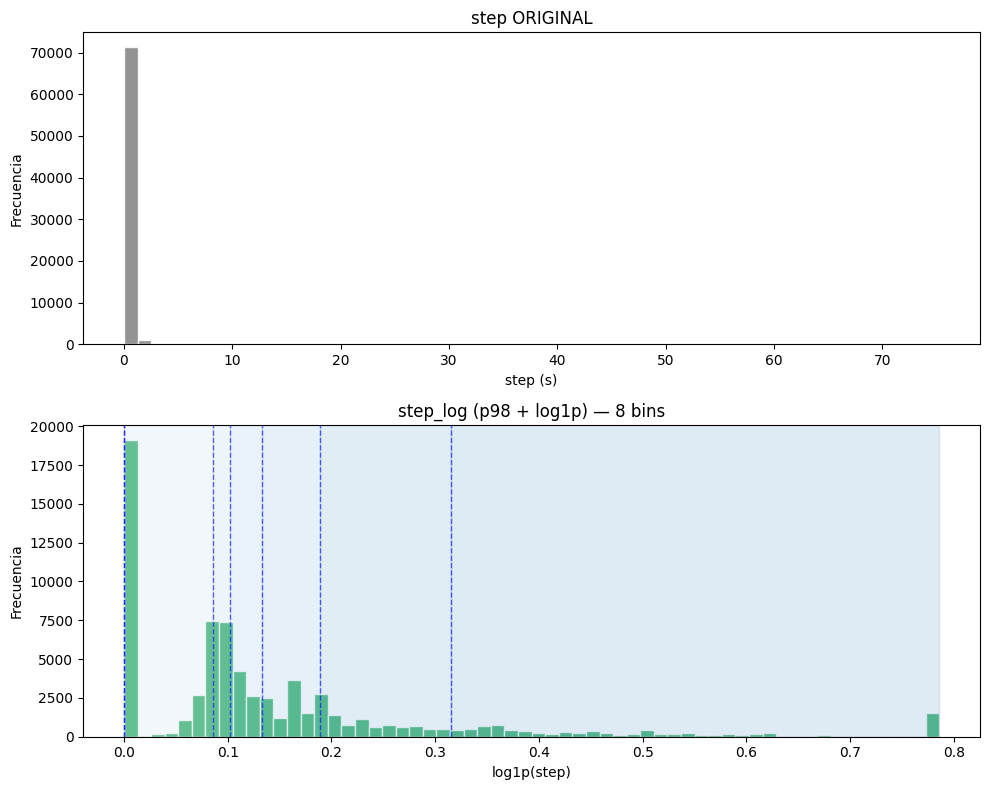

p98=1.194 | edges=[0.    0.    0.    0.086 0.102 0.133 0.189 0.315 0.786]


In [13]:
p98 = df_train["step"].quantile(0.98)

step = df_train["step"]
step_log = np.log1p(step.clip(0, p98))
edges = np.quantile(step_log, np.linspace(0, 1, N_BINS + 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# Original
ax[0].hist(step, bins=60, color="gray", edgecolor="white", alpha=0.85)
ax[0].set(title="step ORIGINAL", xlabel="step (s)", ylabel="Frecuencia")

# Transformado
ax[1].hist(step_log, bins=60, color="mediumseagreen", edgecolor="white", alpha=0.85)

for i, (l, r) in enumerate(zip(edges[:-1], edges[1:])):
    ax[1].axvspan(l, r, color=plt.cm.Blues(0.2 + 0.6*i/N_BINS), alpha=0.15)

for e in edges[1:-1]:
    ax[1].axvline(e, ls="--", lw=1, color="blue", alpha=0.6)

ax[1].set(title=f"step_log (p98 + log1p) — {N_BINS} bins", xlabel="log1p(step)", ylabel="Frecuencia")

plt.tight_layout()
plt.show()

print(f"p98={p98:.3f} | edges={edges.round(3)}")

### 3.2.2 Duration

Mismo esquema de binning que `step`, aplicado a `duration`.

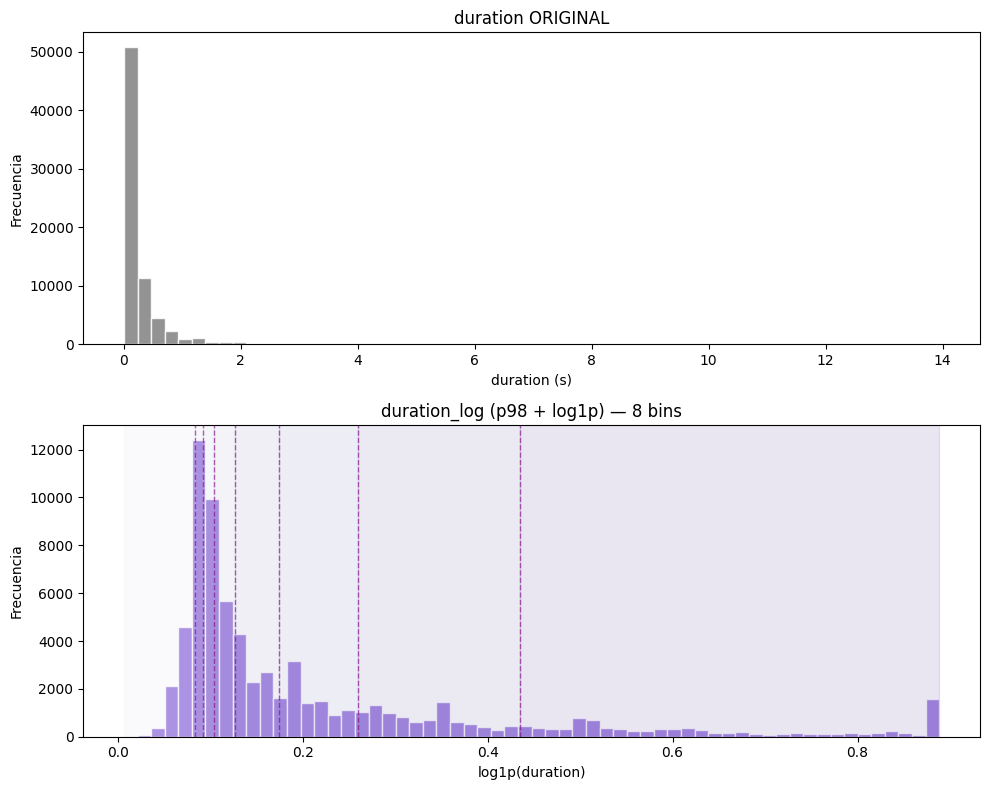

p98=1.431 | edges=[0.007 0.084 0.092 0.104 0.127 0.175 0.26  0.435 0.888]


In [14]:
p98 = df_train["duration"].quantile(0.98)

dur = df_train["duration"]
dur_log = np.log1p(dur.clip(0, p98))
edges = np.quantile(dur_log, np.linspace(0, 1, N_BINS + 1))

fig, ax = plt.subplots(2, 1, figsize=(10, 8))

# ORIGINAL
ax[0].hist(dur, bins=60, color="gray", edgecolor="white", alpha=0.85)
ax[0].set(title="duration ORIGINAL", xlabel="duration (s)", ylabel="Frecuencia")

# TRANSFORMADO
ax[1].hist(dur_log, bins=60, color="mediumpurple", edgecolor="white", alpha=0.85)

for i, (l, r) in enumerate(zip(edges[:-1], edges[1:])):
    ax[1].axvspan(l, r, color=plt.cm.Purples(0.2 + 0.6*i/N_BINS), alpha=0.15)

for e in edges[1:-1]:
    ax[1].axvline(e, ls="--", lw=1, color="purple", alpha=0.6)

ax[1].set(title=f"duration_log (p98 + log1p) — {N_BINS} bins", xlabel="log1p(duration)", ylabel="Frecuencia")

plt.tight_layout()
plt.show()

print(f"p98={p98:.3f} | edges={edges.round(3)}")

<a id='sec33'></a>
## 3.3 Transformación completa

La función `transform_df` toma un DataFrame y le aplica la descomposición del pitch y el binning, devolviendo también los parámetros necesarios para usar esa misma transformación después. Por otro lado, `df_to_sequences` convierte el DataFrame en secuencias de tokens agrupadas por canción y por pista.

In [15]:
def transform_df(df, n_bins=8, p=0.98):
    x = df.copy()

    # Pitch
    pitch_class = (x["pitch"] % 12).astype(int)
    octave      = (x["pitch"] // 12).astype(int)

    # Step
    p_step_val  = x["step"].quantile(p)
    step_log    = np.log1p(x["step"].clip(0, p_step_val))
    step_edges  = np.quantile(step_log, np.linspace(0, 1, n_bins + 1))
    step_bin    = np.digitize(step_log, step_edges[1:-1]).astype(int)

    # Duration
    p_dur_val   = x["duration"].quantile(p)
    dur_log     = np.log1p(x["duration"].clip(0, p_dur_val))
    dur_edges   = np.quantile(dur_log, np.linspace(0, 1, n_bins + 1))
    dur_bin     = np.digitize(dur_log, dur_edges[1:-1]).astype(int)

    out = pd.DataFrame({
        "song_id":     x["song_id"].values,
        "song_name":   x["song_name"].values,
        "n_pista":     x["n_pista"].values,
        "pitch_class": pitch_class.values,
        "octave":      octave.values,
        "step_bin":    step_bin,
        "dur_bin":     dur_bin,
    })

    params = {
        "p_step":     p_step_val,
        "p_dur":      p_dur_val,
        "step_edges": step_edges,
        "dur_edges":  dur_edges,
        "n_bins":     n_bins,
    }
    return out, params


def df_to_sequences(df):
    sequences = []
    for _, group in df.groupby(["song_id", "n_pista"]):
        seq = group[[
            "pitch_class",
            "octave",
            "step_bin",
            "dur_bin",
        ]].values.tolist()
        sequences.append(seq)
    return sequences


<a id='sec34'></a>
## 3.4 Augmentación por transposición

Para aumentar el volumen de datos disponibles para el entrenamiento, se aplica una técnica de augmentación basada en la transposición musical. La idea es desplazar toda una secuencia de notas un número fijo de semitonos hacia arriba o hacia abajo, generando así múltiples versiones de una misma canción en distintas tonalidades.

Por ejemplo, si una nota original es Do (`pitch_class = 0`) y se transpone `+2` semitonos, Do pasa a ser Re, Re pasa a Mi, y así sucesivamente en toda la secuencia. De forma análoga, una transposición de `−1` semitono convierte Do en Si, Re en Do\#, etc. El proceso se aplica de forma uniforme a todas las notas de la secuencia, de modo que se conserva íntegramente la estructura relativa de la melodía —los intervalos entre notas permanecen iguales— y únicamente cambia la tonalidad.

Se generan versiones transpuestas con desplazamientos de `−2, −1, 0, +1, +2` semitonos, lo que multiplica el tamaño del dataset por hasta 5×. Las versiones cuyas notas salen del rango MIDI válido (A0–C8, MIDI 21–108) se descartan para evitar notas inaudibles o fuera del registro del piano. Cabe destacar que esta augmentación se aplica **únicamente al set de entrenamiento**, manteniendo val y test intactos para garantizar una evaluación sin contaminación.

### Demostración de cambio de semitonos en canción conocida

In [15]:
melody = np.array([60,60,67,67,69,69,67,65,65,64,64,62,62,60])

f = lambda m: 440 * 2**((m-69)/12)
synth = lambda m: np.concatenate([np.sin(2*np.pi*f(n)*np.linspace(0,0.4,8000)) for n in m])

In [16]:
Audio(synth(melody), rate=30000)      # original

In [17]:
Audio(synth(melody-1), rate=30000)    # -1 semitono

In [18]:
Audio(synth(melody+2), rate=30000)    # +2 semitonos

### Aumentación en datos de entrenamiento


Este módulo implementa la augmentación de datos por transposición en el conjunto de entrenamiento. 

La función `transpose_sequence` toma una secuencia y desplaza todas sus notas un número fijo de semitonos. Si al realizar esta transposición alguna nota queda por fuera del rango válido del piano usado por *Beethoven* (entre A0 y C8), la secuencia completa se descarta para evitar generar datos irreales.

Por su parte, la función `augment_train_data` aplica este proceso a todas las secuencias del conjunto de entrenamiento. Para cada canción y pista, genera múltiples versiones transpuestas usando distintos desplazamientos en semitonos. Cada versión válida se guarda como una nueva secuencia independiente con un identificador único.

Este procedimiento aumenta el tamaño del dataset sin alterar la estructura musical de las piezas, ya que conserva los intervalos entre notas. De esta forma, el modelo puede aprender patrones más generales y volverse más robusto frente a cambios de tonalidad.

In [16]:
MIN_PITCH, MAX_PITCH = 21, 108
TRANSPOSE_SHIFTS = [-2, -1, 0, 1, 2]

def transpose_sequence(df, s):
    p = df['pitch'] + s
    if p.min() < MIN_PITCH or p.max() > MAX_PITCH:
        return None
    out = df.copy()
    out['pitch'] = p
    return out

def augment_train_data(df, shifts=TRANSPOSE_SHIFTS):
    parts, n_orig, n_valid, n_disc = [], 0, 0, 0
    new_id = int(df['song_id'].max()) + 1

    for _, g in df.groupby(['song_id', 'n_pista'], sort=False):
        n_orig += 1
        for s in shifts:
            t = transpose_sequence(g, s)
            if t is None:
                n_disc += 1
                continue
            t = t.copy()
            t['song_id'] = new_id; new_id += 1
            parts.append(t); n_valid += 1

    df_aug = pd.concat(parts, ignore_index=True)

    print(f'Augmentación:')
    print(f'  Originales : {n_orig}')
    print(f'  Notas      : {len(df):,} → {len(df_aug):,} ({len(df_aug)/len(df):.2f}x)')
    
    return df_aug

In [17]:
df_train_aug = augment_train_data(df_train)

Augmentación:
  Originales : 37
  Notas      : 72,622 → 363,110 (5.00x)


<a id='sec35'></a>
## 3.5 Secuencias de entrenamiento

Aplica la transformación al DataFrame augmentado y construye las secuencias de tokens que alimentarán el DataLoader.

In [18]:
df_train_t, params = transform_df(df_train_aug, n_bins=8)
df_train_t

,song_id,song_name,n_pista,pitch_class,octave,step_bin,dur_bin
0,23,appass_1.mid,1,10,4,2,6
1,23,appass_1.mid,1,6,4,7,4
2,23,appass_1.mid,1,3,4,4,7
3,23,appass_1.mid,1,6,4,7,6
4,23,appass_1.mid,1,10,4,7,2
...,...,...,...,...,...,...,...
363105,207,mond_3.mid,2,10,3,2,6
363106,207,mond_3.mid,2,3,4,7,6
363107,207,mond_3.mid,2,10,3,2,6
363108,207,mond_3.mid,2,3,3,2,6


In [19]:
train_sequences = df_to_sequences(df_train_t)
print(f"Número de secuencias: {len(train_sequences)}")
print(f"Numero de notas en la primer secuencia: {len(train_sequences[0])}")
print(f"Ejemplo de una nota: {train_sequences[0][0]} [](pitch_class, octave, step_bin, dur_bin)")

Número de secuencias: 185
Numero de notas en la primer secuencia: 3207
Ejemplo de una nota: [10, 4, 2, 6] [](pitch_class, octave, step_bin, dur_bin)


<a id='sec4'></a>
# 4. DataLoader

<a id='sec41'></a>
## 4.1 Splits y transformación sin leakage

La función `apply_params` aplica a los conjuntos de validación y realiza las mismas transformaciones calculadas sobre el conjunto de entrenamiento, como los bordes de los bins y los percentiles. De esta forma, se evita el data leakage y se asegura que todos los datos estén en la misma escala. 

Posteriormente, se generan las secuencias correspondientes para los tres conjuntos: entrenamiento, validación y prueba.

In [ ]:
BLOCK_SIZE = 64
BATCH_SIZE = 64

# Transformar val y test con los parámetros del train
def apply_params(df, p):
    x     = df.copy()
    s_log = np.log1p(x['step'].clip(0, p['p_step']))
    d_log = np.log1p(x['duration'].clip(0, p['p_dur']))
    return pd.DataFrame({
        'song_id':     x['song_id'].values,
        'song_name':   x['song_name'].values,
        'n_pista':     x['n_pista'].values,
        'pitch_class': (x['pitch'] % 12).astype(int).values,
        'octave':      (x['pitch'] // 12).astype(int).values,
        'step_bin':    np.digitize(s_log, p['step_edges'][1:-1]).astype(int),
        'dur_bin':     np.digitize(d_log, p['dur_edges'][1:-1]).astype(int),
    })

df_val_t  = apply_params(df_val,  params)
df_test_t = apply_params(df_test, params)

train_seqs = df_to_sequences(df_train_t)
val_seqs   = df_to_sequences(df_val_t)
test_seqs  = df_to_sequences(df_test_t)

print(f'Secuencias — train: {len(train_seqs)}  val: {len(val_seqs)}  test: {len(test_seqs)}')


Secuencias — train: 185  val: 4  test: 6


<a id='sec42'></a>
## 4.2 Clase MusicDataLoader

El `MusicDataLoader` implementa ventanas deslizantes sobre las secuencias: dado un `BLOCK_SIZE = 64`, cada ejemplo consiste en 64 notas consecutivas como entrada (X) y la nota siguiente como etiqueta (Y). El loader baraja los índices en cada época para evitar que el modelo vea siempre los ejemplos en el mismo orden.

In [24]:
class MusicDataLoader:
    def __init__(self, seqs, block_size):
        self.block_size = block_size
        self.seqs = [torch.tensor(s, dtype=torch.float32) for s in seqs]
        self.idx  = [(si, st) for si, s in enumerate(self.seqs)
                     for st in range(len(s) - block_size)]
        self._shuffle()

    def _shuffle(self):
        self.order, self.pos = np.random.permutation(len(self.idx)), 0

    def get_batch(self, batch_size):
        batch = self.order[self.pos : self.pos + batch_size]
        self.pos += len(batch)
        if len(batch) < batch_size:
            self._shuffle()
            if not len(batch):
                batch, self.pos = self.order[:batch_size], batch_size
        xs, ys = [], []
        for i in batch:
            si, st = self.idx[i]
            xs.append(self.seqs[si][st : st + self.block_size])
            ys.append(self.seqs[si][st + self.block_size])
        return torch.stack(xs), torch.stack(ys)

    @property
    def n_examples(self): return len(self.idx)


train_loader = MusicDataLoader(train_seqs, BLOCK_SIZE)
val_loader   = MusicDataLoader(val_seqs,   BLOCK_SIZE)
test_loader  = MusicDataLoader(test_seqs,  BLOCK_SIZE)

xb, yb = train_loader.get_batch(BATCH_SIZE)
print(f'Ventanas — train: {train_loader.n_examples:,}  val: {val_loader.n_examples:,}  test: {test_loader.n_examples:,}')
print(f'x: {tuple(xb.shape)}  →  (batch, contexto, features)')
print(f'y: {tuple(yb.shape)}  →  nota objetivo')

Ventanas — train: 351,270  val: 7,807  test: 3,716
x: (64, 64, 4)  →  (batch, contexto, features)
y: (64, 4)  →  nota objetivo


<a id='sec5_exp'></a>
# 5. Experimentación previa

A continuación, se presentan de forma detallada los experimentos realizados por el equipo. Estos evidencian una exploración variada de distintas configuraciones, lo que permitió, de manera conjunta, seleccionar la mejor arquitectura, el preprocesamiento más adecuado y otros parámetros relevantes que se mostraran en la arquitectura final (Dual LSTM)

Asimismo, se describen los resultados obtenidos en cada caso.

### Experimento 1: Arquitectura Base y Modelado Mixto

Se entrenó un modelo LSTM de una sola capa con dimensión oculta de 128 utilizando PyTorch, con el objetivo de generar música a partir de un conjunto limitado de archivos MIDI.

En esta primera aproximación, se trabajó directamente sobre la representación original de los datos. El pitch se modeló como una variable categórica con 128 posibles clases (notas MIDI), mientras que las variables temporales (*step*, *duration* y *velocity*) se trataron como valores continuos.

Para el entrenamiento, se utilizó una función de pérdida mixta, combinando:
- *CrossEntropyLoss* para la predicción del pitch  
- *MAE (Mean Absolute Error)* para las variables continuas (*step*, *duration*, *velocity*)  

La arquitectura empleada fue relativamente simple, con embeddings de baja dimensionalidad (16 en total) y una única capa LSTM, lo que limitó su capacidad para capturar la complejidad de la estructura musical.

Durante el entrenamiento, se evidenció un sobreajuste temprano, reflejado en un incremento del *val_loss* desde etapas iniciales. Adicionalmente, las métricas obtenidas fueron bajas y, en la fase de generación, el modelo produjo secuencias poco coherentes y altamente repetitivas.

Estos resultados pusieron en evidencia varias limitaciones del enfoque: la dificultad de modelar directamente las 128 posibles notas, la inestabilidad de la regresión en variables temporales con distribuciones sesgadas, y la incapacidad del modelo para capturar dependencias de largo plazo.

Como consecuencia, se planteó la necesidad de rediseñar tanto la representación de los datos como la arquitectura en los experimentos posteriores.

---

### Experimento 2: Entrenamiento y Regularización del Modelo LSTM

Se entrenó un modelo LSTM de 2 capas con dimensión oculta de 128 utilizando PyTorch, con el objetivo de generar música al estilo de Beethoven a partir de un conjunto de 29 archivos MIDI.

En este caso, la representación de entrada se modificó mediante la descomposición del pitch en *pitch_class* (12 categorías) y *octave* (11 categorías), lo que facilitó el aprendizaje. Asimismo, las variables *step* y *duration* fueron discretizadas en bins, transformando el problema en tareas de clasificación.

Se utilizó una función de pérdida compuesta, ponderando cada componente según su importancia:
- *2 × CrossEntropyLoss* para *pitch_class*
- *1.5 × CrossEntropyLoss* para *octave*
- *1 × CrossEntropyLoss* para *step*
- *1 × CrossEntropyLoss* para *duration*
- *0.5 × MAE* para *velocity*

En las primeras pruebas, el modelo volvió a presentar sobreajuste temprano, evidenciado por un incremento del *val_loss* desde las primeras épocas. Para mitigarlo, se realizaron varios ajustes de regularización y optimización:
- Aumento del *dropout* a 0.5  
- Reducción del *learning rate* a 5e-4  
- Incremento del *weight decay* a 5e-3  
- Uso de *label smoothing* de 0.15  
- Aumento del contexto de entrada a secuencias de 64 notas  

Con estos cambios, el entrenamiento se estabilizó, logrando un comportamiento en el que el *val_loss* se mantiene por debajo del *train_loss*, lo que indica una mejor capacidad de generalización.

Finalmente, se generaron tres piezas musicales utilizando diferentes estrategias de sampling (*top-k*, *top-p* y alta temperatura), lo que permitió evaluar su impacto en la diversidad y calidad de la música generada.

---

<a id='sec6'></a>
# 6. Arquitectura Dual LSTM


Con el fin de mejorar la calidad de la generación musical, se diseñó una arquitectura compuesta por dos redes LSTM especializadas, cada una enfocada en un subconjunto de variables. La motivación principal fue que no todas las características tienen la misma dificultad ni el mismo impacto en el resultado final. En particular, las variables relacionadas con el pitch son las más críticas, ya que pequeños errores pueden afectar significativamente la musicalidad. Por ello, se separó la predicción tonal de la predicción rítmica.

La primera red, denominada NoteNet1, se encarga de predecir pitch_class y octave. Estas variables representan la clase de nota (12 categorías) y la octava (11 niveles), lo que reduce la complejidad frente a modelar directamente las 128 notas MIDI. La entrada consiste únicamente en secuencias de estas dos variables, las cuales se transforman mediante embeddings de dimensión 32. Estos embeddings se concatenan y se procesan con una arquitectura de dos capas LSTM con 512 unidades ocultas. A partir de la salida final, se utilizan dos cabezas MLP independientes para predecir cada variable.

La segunda red, NoteNet2, se enfoca en la predicción de step y duration, es decir, la estructura temporal. A diferencia de la anterior, recibe como entrada el conjunto completo de variables: pitch_class, octave, step y duration. Cada una se representa mediante embeddings de distinta dimensión según su complejidad: 32 para pitch_class y octave, 4 para step y 8 para duration. Estos embeddings se concatenan y se introducen en una LSTM de dos capas con 512 unidades ocultas. A partir de su salida, se utilizan dos capas lineales para predecir los bins de step y duration. La variable velocity no se modela directamente y se fija en un valor constante durante la generación (media de velocity vista en el EDA).

Ambas redes trabajan de forma autoregresiva y complementaria. NoteNet1 predice la información tonal, mientras que NoteNet2 predice la rítmica. En cada paso, las predicciones generadas se reutilizan como entrada en el siguiente, permitiendo que ambas redes se retroalimenten y mantengan coherencia en la secuencia.

El entrenamiento se realiza mediante funciones de costo compuestas basadas en CrossEntropyLoss. En NoteNet1, se asigna mayor peso a pitch_class que a octave, priorizando la variable más crítica. En NoteNet2, se utilizan pérdidas para step y duration, con un mayor label smoothing en esta última para favorecer la generalización.

Finalmente, el modelo se entrena utilizando secuencias de longitud 64, es decir, recibe 64 notas consecutivas y predice la siguiente. Este tamaño de contexto permite capturar dependencias melódicas y rítmicas de mediano plazo. 

---


<a id='sec61'></a>
## 6.1 Diagrama arquitectura seleccionada

Visualización de la arquitectura dual: entradas, embeddings, LSTM, cabezas de salida y nota generada combinada.

![Arquitectura del modelo](Arquitectura.jpeg)

**Nota sobre los embeddings:** La notación vocab→dim dentro de las cajas de *embeddings* (12→32 para pitch_class, 11→32 para octave, 8→4 para step) indica que el vocabulario tiene **vocab** categorías posibles y cada una se representa como un vector denso de **dim** dimensiones. La entrada real es un índice entero escalar, no un vector de **vocab** dimensiones, el embedding actúa como una tabla de lookup aprendible de forma (**vocab**, **dim**).

---

<a id='sec62'></a>
## 6.2 Hiperparámetros y vocabularios

Dimensiones de embeddings, capas LSTM, dropout y vocabularios de cada variable discreta.

In [25]:
# ── Hiperparámetros ──────────────────────────────────────────────────
LSTM_LAYERS = 2
HIDDEN_DIM  = 512
DROPOUT     = 0.4

EMB_PITCH   = 32   # pitch_class  (vocab = 12)
EMB_OCTAVE  = 32   # octave       (vocab = 11)
EMB_STEP    = 4    # step_bin     (vocab = 8)
EMB_DUR     = 8    # dur_bin      (vocab = 8)

INPUT_DIM_1 = EMB_PITCH + EMB_OCTAVE                         # Net1: pitch + octave
INPUT_DIM_2 = EMB_PITCH + EMB_OCTAVE + EMB_STEP + EMB_DUR   # Net2: todos excepto velocity

print(f'LSTM: {LSTM_LAYERS} capas  |  hidden: {HIDDEN_DIM}  |  dropout: {DROPOUT}')
print(f'INPUT_DIM_1 (NoteNet1): {INPUT_DIM_1}  |  INPUT_DIM_2 (NoteNet2): {INPUT_DIM_2}')

LSTM: 2 capas  |  hidden: 512  |  dropout: 0.4
INPUT_DIM_1 (NoteNet1): 64  |  INPUT_DIM_2 (NoteNet2): 76


<a id='sec63'></a>
## 6.3 Modelos: NoteNet1 y NoteNet2

Cada red tiene sus propios embeddings, una LSTM de 2 capas y cabezas de clasificación independientes.

### NoteNet1: LSTM para predecir *Pitch_class* y *Octave*

**NoteNet1** recibe únicamente las variables melódicas *[pitch_class, octave]* como entrada. Cada variable se proyecta a un espacio de embedding denso (32d cada una), se concatenan (64d total) y se procesan con una LSTM de 2 capas y 512 unidades. El estado oculto final alimenta dos cabezas MLP independientes: una predice *pitch_class* (12 clases) y otra predice *octave* (11 clases).

In [26]:
class NoteNet1(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.emb_pitch  = nn.Embedding(PITCH_CLASS_VOCAB, EMB_PITCH)
        self.emb_octave = nn.Embedding(OCTAVE_VOCAB, EMB_OCTAVE)

        self.lstm = nn.LSTM(
            INPUT_DIM_1, HIDDEN_DIM, LSTM_LAYERS,
            batch_first=True, dropout=DROPOUT
        )

        # Cabeza MLP para pitch
        self.head_pitch = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, PITCH_CLASS_VOCAB)
        )

        # Cabeza MLP para octave
        self.head_octave = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, OCTAVE_VOCAB)
        )

    def forward(self, x):
        # x: (batch, seq, 2) — solo [pitch_class, octave]
        pc   = x[:, :, 0].long()
        oct_ = x[:, :, 1].long()

        emb = torch.cat([self.emb_pitch(pc), self.emb_octave(oct_)], dim=-1)

        h = self.lstm(emb)[0][:, -1, :]   # (batch, HIDDEN_DIM)

        return {
            'pitch': self.head_pitch(h),
            'octave': self.head_octave(h)
        }


net1 = NoteNet1()

print(f'NoteNet1 parámetros: {sum(p.nelement() for p in net1.parameters()):,}')

NoteNet1 parámetros: 3,487,223


### NoteNet2: LSTM para predecir *Step* y *Duration*

**NoteNet2** recibe la secuencia completa *[pitch_class, octave, step_bin, dur_bin]*. El pitch se incluye como contexto porque el ritmo en música clásica puede depender de la nota, por ejemplo, notas graves pueden ir con mayor duración. Las cuatro variables se representan con *embeedings* de diferente tamaño (32 para pitch_class y octave, 4 step y 8 duration) y se concatenan (76d total). La LSTM de 2 capas y 512 unidades genera dos predicciones: *step_bin* (8 clases) y *dur_bin* (8 clases).

In [27]:
class NoteNet2(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.emb_pitch  = nn.Embedding(PITCH_CLASS_VOCAB, EMB_PITCH)
        self.emb_octave = nn.Embedding(OCTAVE_VOCAB,      EMB_OCTAVE)
        self.emb_step   = nn.Embedding(N_BINS,            EMB_STEP)
        self.emb_dur    = nn.Embedding(N_BINS,            EMB_DUR)
        self.lstm = nn.LSTM(INPUT_DIM_2, HIDDEN_DIM, LSTM_LAYERS,
                            batch_first=True, dropout=DROPOUT)
        self.head_step = nn.Linear(HIDDEN_DIM, N_BINS)
        self.head_dur  = nn.Linear(HIDDEN_DIM, N_BINS)

    def forward(self, x):
        pc   = x[:, :, 0].long()
        oct_ = x[:, :, 1].long()
        st   = x[:, :, 2].long()
        dur  = x[:, :, 3].long()
        emb  = torch.cat([self.emb_pitch(pc), self.emb_octave(oct_),
                          self.emb_step(st),  self.emb_dur(dur)], dim=-1)
        h = self.lstm(emb)[0][:, -1, :]
        return {'step': self.head_step(h), 'dur': self.head_dur(h)}


net2 = NoteNet2()
print(f'NoteNet2 parámetros: {sum(p.nelement() for p in net2.parameters()):,}')

NoteNet2 parámetros: 3,318,608


In [28]:
total_p = sum(p.nelement() for p in list(net1.parameters()) + list(net2.parameters()))
print(f'Total parámetros (ambas redes): {total_p:,}')

Total parámetros (ambas redes): 6,805,831


<a id='sec7'></a>
# 7. Entrenamiento

<a id='sec71'></a>
## 7.1 Funciones de pérdida y pesos

La función de pérdida se define de manera independiente para cada red, combinando las pérdidas asociadas a las variables que cada una predice.

En el caso de **NoteNet1**, la pérdida se construye como una combinación ponderada de las entropías cruzadas de *pitch_class* y *octave*:

$$
loss_{net1} = W_{PC} \cdot CE(pitch\_class) + W_{OCT} \cdot CE(octave)
$$

donde se utilizan los pesos W_{PC} = 2 y W_{OCT} = 1.

Para **NoteNet2**, la pérdida combina las variables rítmicas:

$$
loss_{net2} = CE(step) + CE(duration)
$$

incluyendo un suavizado adicional en la variable *duration*, con el fin de mejorar la estabilidad del entrenamiento en esta predicción.

La elección de estos pesos y configuraciones se realizó de manera empírica, a partir de la experimentación durante el entrenamiento del modelo. En particular, se asignó un mayor peso a *pitch_class* debido a que fue la variable más difícil de predecir, lo que justificó aumentar su contribución en la función de pérdida de NoteNet1.

Dado que todas las variables a predecir son categóricas, se utiliza la *Cross-Entropy* como función base. Sin embargo, al tratarse de múltiples salidas por red, la función de pérdida final es una composición de pérdidas, donde cada término corresponde a una variable objetivo y se pondera según su importancia relativa.

In [29]:
if TRAIN:
    ce_loss     = nn.CrossEntropyLoss(label_smoothing=0.05)
    ce_loss_dur = nn.CrossEntropyLoss(label_smoothing=0.10)

    W_PC, W_OCT      = 2.0, 1.0
    W_STEP, W_DUR    = 1.0, 1.0 

    LOSS_KEYS_1 = ['total1', 'pc', 'oct']
    LOSS_KEYS_2 = ['total2', 'step', 'dur']

    def loss_net1(out, y):
        l_pc  = ce_loss(out['pitch'],  y[:, 0].long())
        l_oct = ce_loss(out['octave'], y[:, 1].long())
        return W_PC * l_pc + W_OCT * l_oct, l_pc, l_oct

    def loss_net2(out, y):
        l_step = ce_loss(    out['step'], y[:, 2].long())
        l_dur  = ce_loss_dur(out['dur'],  y[:, 3].long())
        return W_STEP * l_step + W_DUR * l_dur, l_step, l_dur


<a id='sec72'></a>
## 7.2 Métricas: *Perplexity* como métrica de evaluación

Como métrica principal de evaluación se utiliza la *Perplexity*, definida como:

$$
ppl = \exp(\text{Cross-Entropy})
$$

La Perplexity es especialmente adecuada en este contexto, ya que se trata de un modelo generativo que predice variables categóricas de forma secuencial. Esta métrica permite interpretar qué tan seguro o incierto está el modelo al predecir la siguiente variable.

En términos intuitivos, la Perplexity puede entenderse como el número efectivo de opciones entre las que el modelo está “dudando”. Por ejemplo:
- Un valor cercano a **1** indica que el modelo está muy seguro.
- Valores más altos indican mayor incertidumbre en la predicción.

En general, entre menor sea la Perplexity, mejor es el desempeño del modelo. Sin embargo, es importante tener en cuenta que el valor “bueno” depende del número de clases de cada variable.

El peor caso ocurre cuando el modelo asigna probabilidades uniformes, es decir, cuando no ha aprendido nada. En ese caso, la Perplexity es igual al número de clases posibles:

- Para *pitch_class* (12 clases): peor caso \( ppl = 12 \)
- Para *octave* (11 clases): peor caso \( ppl = 11 \)
- Para *step_bin* (8 clases): peor caso \( ppl = 8 \)
- Para *dur_bin* (8 clases): peor caso \( ppl = 8 \)

Por lo tanto, los valores de Perplexity deben interpretarse relativamente a cada variable. Por ejemplo, una Perplexity de 3 puede ser buena para *pitch_class*, pero no necesariamente para una variable con menos clases.

En resumen, la *Perplexity* permite evaluar de manera interpretable la calidad del modelo, indicando cuántas opciones “efectivas” considera en promedio al realizar una predicción.

In [30]:
if TRAIN:
    def compute_perplexity(loss):
        return math.exp(loss)

<a id='sec73'></a>
## 7.3 Hiperparámetros de entrenamiento

Se definieron los principales hiperparámetros que controlan el proceso de entrenamiento del modelo, incluyendo la tasa de aprendizaje, el número de épocas, la frecuencia de evaluación y el criterio de *early stopping*.

La tasa de aprendizaje se fijó en *2e-3*, permitiendo actualizaciones relativamente rápidas de los pesos durante el entrenamiento. El modelo se entrena durante un máximo de **20 épocas**, recorriendo el conjunto de datos completo en cada una.

Para monitorear el desempeño del modelo, se realiza una evaluación cada **100 pasos de entrenamiento**, utilizando **100 batches** para estimar la métrica de validación. Esto permite tener un seguimiento periódico sin incurrir en un alto costo computacional.

Se implementa un mecanismo de **early stopping** con una paciencia de **50 evaluaciones**, deteniendo el entrenamiento si no se observan mejoras en la métrica de validación durante este intervalo.

Adicionalmente, se calcula el número de pasos por época como:

$$
\text{steps\_per\_epoch} = \frac{N_{\text{ejemplos}}}{\text{batch size}}
$$

y el número total de pasos de entrenamiento como:

$$
\text{max\_steps} = \text{epochs} \times \text{steps\_per\_epoch}
$$


In [31]:
if TRAIN:
    LR           = 2e-3
    N_EPOCHS     = 20
    EVAL_EVERY   = 100
    EVAL_BATCHES = 100
    PATIENCE     = 50

    steps_per_epoch = int(train_loader.n_examples / BATCH_SIZE)
    MAX_STEPS       = N_EPOCHS * steps_per_epoch
    print(f'steps_per_epoch: {steps_per_epoch:,}')
    print(f'Entrenando {N_EPOCHS} epochs → {MAX_STEPS:,} pasos totales')


steps_per_epoch: 5,488
Entrenando 20 epochs → 109,760 pasos totales


<a id='sec74'></a>
## 7.4 Proceso de entrenamiento y validación

El entrenamiento del modelo se realiza durante un número definido de pasos (o épocas), optimizando de manera simultánea las dos redes que componen la arquitectura. Durante este proceso, se busca que ambas redes aprendan a predecir correctamente sus respectivas variables a partir de las secuencias de entrada.

Para evaluar el desempeño del modelo, se utiliza *loss* basada en entropía cruzada, junto con la *Perplexity*, que permite interpretar qué tan segura es la red al hacer sus predicciones. 
Cada cierto número de pasos se calculan estas métricas tanto en el conjunto de entrenamiento como en el de validación. Esto permite hacer seguimiento al aprendizaje del modelo a lo largo del tiempo y analizar su comportamiento.

A partir de estas evaluaciones periódicas, se observa si el modelo está mejorando, si se mantiene estable o si comienza a haber *overfitting*. En caso de que la pérdida en validación deje de mejorar durante varios ciclos consecutivos, se detiene el entrenamiento de manera anticipada *early stopping*, conservando los mejores pesos encontrados.

In [32]:
if TRAIN:
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    net1   = net1.to(device)
    net2   = net2.to(device)


    @torch.no_grad()
    def estimate_losses(loader, n=EVAL_BATCHES):
        net1.eval(); net2.eval()
        a1 = torch.zeros(len(LOSS_KEYS_1))
        a2 = torch.zeros(len(LOSS_KEYS_2))
        for _ in range(n):
            x, y = loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)
            a1 += torch.tensor([l.item() for l in loss_net1(net1(x[:, :, :2]), y)])
            a2 += torch.tensor([l.item() for l in loss_net2(net2(x), y)])
        net1.train(); net2.train()
        return (a1 / n).tolist(), (a2 / n).tolist()


    def training_loop(net1, net2, train_loader, val_loader,
                    lr=LR, max_steps=MAX_STEPS, weight_decay=1e-4,
                    patience=PATIENCE):
        opt1 = torch.optim.Adam(net1.parameters(), lr=lr, weight_decay=weight_decay)
        opt2 = torch.optim.Adam(net2.parameters(), lr=lr, weight_decay=weight_decay)
        h1 = {k: [] for k in [f'train_{k}' for k in LOSS_KEYS_1]
                + [f'val_{k}' for k in LOSS_KEYS_1]}
        h2 = {k: [] for k in [f'train_{k}' for k in LOSS_KEYS_2]
                + [f'val_{k}' for k in LOSS_KEYS_2]}

        best_val_1, best_state_1, no_improve_1, stopped_1 = float('inf'), None, 0, False
        best_val_2, best_state_2, no_improve_2, stopped_2 = float('inf'), None, 0, False
        best_step_1, best_step_2 = 0, 0

        net1.train(); net2.train()
        print(f'Entrenando {max_steps} pasos en {device}')
        for step in range(max_steps):
            x, y = train_loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)

            if not stopped_1:
                t1, *_ = loss_net1(net1(x[:, :, :2]), y)
                opt1.zero_grad(); t1.backward(); opt1.step()

            if not stopped_2:
                t2, *_ = loss_net2(net2(x), y)
                opt2.zero_grad(); t2.backward(); opt2.step()

            if (step + 1) % EVAL_EVERY == 0 or step == 0 or step == max_steps - 1:
                tr1, tr2 = estimate_losses(train_loader)
                vl1, vl2 = estimate_losses(val_loader)
                for k, tv, vv in zip(LOSS_KEYS_1, tr1, vl1):
                    h1[f'train_{k}'].append(tv); h1[f'val_{k}'].append(vv)
                for k, tv, vv in zip(LOSS_KEYS_2, tr2, vl2):
                    h2[f'train_{k}'].append(tv); h2[f'val_{k}'].append(vv)

                ppl_pc_tr  = compute_perplexity(tr1[1]); ppl_pc_vl  = compute_perplexity(vl1[1])
                ppl_oct_tr = compute_perplexity(tr1[2]); ppl_oct_vl = compute_perplexity(vl1[2])
                ppl_st_tr  = compute_perplexity(tr2[1]); ppl_st_vl  = compute_perplexity(vl2[1])
                ppl_dur_tr = compute_perplexity(tr2[2]); ppl_dur_vl = compute_perplexity(vl2[2])

                stopped_tag = lambda s: ' [STOPPED]' if s else ''
                print(f'Step {step+1:4d} | '
                    f'Net1{stopped_tag(stopped_1)} {tr1[0]:.3f}/{vl1[0]:.3f} '
                    f'[pc {tr1[1]:.2f}/{vl1[1]:.2f}  oct {tr1[2]:.2f}/{vl1[2]:.2f}] '
                    f'ppl [pc {ppl_pc_tr:.1f}/{ppl_pc_vl:.1f}  oct {ppl_oct_tr:.1f}/{ppl_oct_vl:.1f}] | '
                    f'Net2{stopped_tag(stopped_2)} {tr2[0]:.3f}/{vl2[0]:.3f} '
                    f'[step {tr2[1]:.2f}/{vl2[1]:.2f}  dur {tr2[2]:.2f}/{vl2[2]:.2f}] '
                    f'ppl [step {ppl_st_tr:.1f}/{ppl_st_vl:.1f}  dur {ppl_dur_tr:.1f}/{ppl_dur_vl:.1f}]')

                if not stopped_1:
                    if vl1[0] < best_val_1:
                        best_val_1 = vl1[0]; best_step_1 = step + 1
                        best_state_1 = {k: v.cpu().clone() for k, v in net1.state_dict().items()}
                        no_improve_1 = 0
                    else:
                        no_improve_1 += 1
                        if no_improve_1 >= patience:
                            stopped_1 = True
                            print(f'  → Net1 early stop en step {step+1} (mejor val={best_val_1:.4f})')

                if not stopped_2:
                    if vl2[0] < best_val_2:
                        best_val_2 = vl2[0]; best_step_2 = step + 1
                        best_state_2 = {k: v.cpu().clone() for k, v in net2.state_dict().items()}
                        no_improve_2 = 0
                    else:
                        no_improve_2 += 1
                        if no_improve_2 >= patience:
                            stopped_2 = True
                            print(f'  → Net2 early stop en step {step+1} (mejor val={best_val_2:.4f})')

                if stopped_1 and stopped_2:
                    print(f'Ambas redes detenidas en step {step+1}.')
                    break

        net1.load_state_dict({k: v.to(device) for k, v in best_state_1.items()})
        net2.load_state_dict({k: v.to(device) for k, v in best_state_2.items()})
        print(f'Pesos restaurados — Net1 val={best_val_1:.4f}  Net2 val={best_val_2:.4f}')
        return h1, h2, best_step_1, best_step_2, best_val_1, best_val_2


    h1, h2, best_step_1, best_step_2, best_val_1, best_val_2 = training_loop(net1, net2, train_loader, val_loader)


Entrenando 109760 pasos en cuda
Step    1 | Net1 7.334/7.318 [pc 2.48/2.48  oct 2.37/2.36] ppl [pc 12.0/11.9  oct 10.7/10.6] | Net2 3.997/4.042 [step 1.94/1.96  dur 2.05/2.08] ppl [step 7.0/7.1  dur 7.8/8.0]
Step  100 | Net1 5.963/5.953 [pc 2.43/2.40  oct 1.10/1.16] ppl [pc 11.4/11.0  oct 3.0/3.2] | Net2 2.203/2.251 [step 1.05/1.03  dur 1.15/1.22] ppl [step 2.9/2.8  dur 3.2/3.4]
Step  200 | Net1 5.734/5.619 [pc 2.32/2.27  oct 1.08/1.07] ppl [pc 10.2/9.7  oct 3.0/2.9] | Net2 2.124/2.237 [step 1.02/1.05  dur 1.11/1.18] ppl [step 2.8/2.9  dur 3.0/3.3]
Step  300 | Net1 5.520/5.600 [pc 2.24/2.27  oct 1.05/1.06] ppl [pc 9.4/9.7  oct 2.8/2.9] | Net2 1.966/2.116 [step 0.92/0.96  dur 1.05/1.16] ppl [step 2.5/2.6  dur 2.9/3.2]
Step  400 | Net1 5.477/5.402 [pc 2.21/2.19  oct 1.05/1.01] ppl [pc 9.1/9.0  oct 2.9/2.8] | Net2 1.897/2.068 [step 0.85/0.93  dur 1.04/1.14] ppl [step 2.3/2.5  dur 2.8/3.1]
Step  500 | Net1 5.368/5.374 [pc 2.17/2.17  oct 1.03/1.03] ppl [pc 8.7/8.8  oct 2.8/2.8] | Net2 1.838

<a id='sec75'></a>
## 7.5 Guardar modelo

Se guarda un checkpoint con los pesos de ambas redes y todo lo necesario para realizar inferencia sin necesidad de reentrenar: hiperparámetros, vocabularios y parámetros de preprocesamiento (`params`).


In [33]:
if TRAIN:   
    checkpoint = {
        # Pesos de las dos redes
        'net1_state_dict': net1.state_dict(),
        'net2_state_dict': net2.state_dict(),

        # Parámetros de preprocesamiento (para decodificar bins a valores reales)
        'params': params,

        # Vocabularios
        'PITCH_CLASS_VOCAB': PITCH_CLASS_VOCAB,
        'OCTAVE_VOCAB':      OCTAVE_VOCAB,
        'N_BINS':            N_BINS,

        # Hiperparámetros de arquitectura (necesarios para reconstruir las redes)
        'HIDDEN_DIM':  HIDDEN_DIM,
        'LSTM_LAYERS': LSTM_LAYERS,
        'DROPOUT':     DROPOUT,
        'EMB_PITCH':   EMB_PITCH,
        'EMB_OCTAVE':  EMB_OCTAVE,
        'EMB_STEP':    EMB_STEP,
        'EMB_DUR':     EMB_DUR,

        # Contexto de entrenamiento — referencia, no límite estricto
        'BLOCK_SIZE': BLOCK_SIZE,
    }

    if COLAB :
        CKPT_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/beethoven_dual_lstm.pt'
    else:
        CKPT_PATH = 'beethoven_dual_lstm.pt'

    torch.save(checkpoint, CKPT_PATH)
    print(f'Checkpoint guardado en: {CKPT_PATH}')


Checkpoint guardado en: /content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/beethoven_dual_lstm.pt


<a id='sec8'></a>
# 8. Evaluación — Curvas de pérdida

A continuación se presentan los resultados del modelo sobre los conjuntos de entrenamiento, validación y test. La métrica principal es la *Perplexity*, interpretada como el número efectivo de categorías entre las que el modelo duda al predecir la siguiente nota. Como referencia, el peor caso (modelo sin aprendizaje) corresponde a la *Perplexity* uniforme de cada variable: 12 para *pitch_class*, 11 para *octave* y 8 para *step_bin* y *dur_bin*.

Se evalúan dos componentes por separado: **NoteNet1**, encargada de la predicción tonal (*pitch_class* y *octave*), y **NoteNet2**, encargada de la predicción rítmica (*step* y *duration*). Para cada una se analizan las curvas de pérdida durante el entrenamiento y la *Perplexity* final sobre el conjunto de test.

<a id='sec81'></a>
## 8.1 Curvas de pérdida — NoteNet1

A continuación s emuestran las curvas de aprendizaje de **NoteNet1**, evidenciando como baja la perdida a medida que aumentan los *steps*.

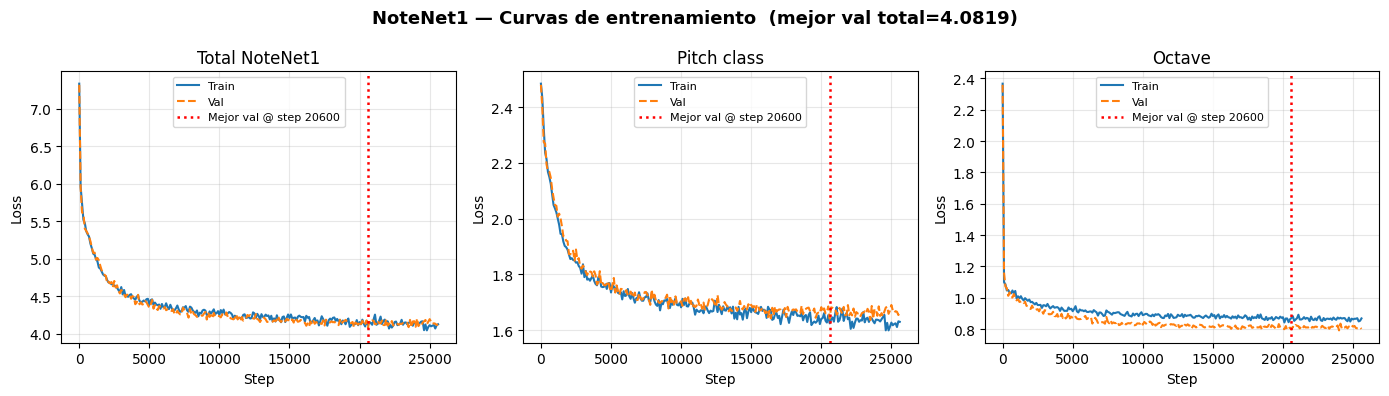

In [34]:
if TRAIN:
    labels1  = {'total1': 'Total NoteNet1', 'pc': 'Pitch class', 'oct': 'Octave'}
    steps_x  = [i * EVAL_EVERY for i in range(len(h1['train_total1']))]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, LOSS_KEYS_1):
        ax.plot(steps_x, h1[f'train_{key}'], label='Train')
        ax.plot(steps_x, h1[f'val_{key}'],   label='Val', linestyle='--')
        ax.axvline(best_step_1, color='red', linestyle=':', linewidth=1.8,
                label=f'Mejor val @ step {best_step_1}')
        ax.set_title(labels1[key]); ax.set_xlabel('Step'); ax.set_ylabel('Loss')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.suptitle(f'NoteNet1 — Curvas de entrenamiento  (mejor val total={best_val_1:.4f})',
                fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


En general, el entrenamiento de **NoteNet1** fue estable y mostró una mejora sostenida a lo largo de los pasos, sin evidenciar un *overfitting* fuerte. Las curvas de entrenamiento y validación para *pitch_class* y *octave* se mantuvieron relativamente cercanas, lo que sugiere que la red logró generalizar de forma adecuada sobre datos no vistos. Además, el uso de *early stopping* permitió conservar el mejor punto de validación alcanzado.

Al comparar la *Perplexity* de validación con el peor caso posible, se observa una reducción importante en ambas variables:

- *pitch_class*: pasó de aproximadamente **11.9** al inicio a **5.2** en su mejor punto de validación.
- *octave*: pasó de aproximadamente **10.6** al inicio a **2.2**.

Esto indica que la red redujo considerablemente su incertidumbre al predecir la siguiente nota. En particular, la variable *octave* fue aprendida con mayor facilidad, alcanzando valores de *Perplexity* mucho más bajos, mientras que *pitch_class* siguió siendo la tarea más compleja, aunque también presentó una mejora clara frente al caso uniforme.

En conclusión, los resultados de **NoteNet1** muestran que la red sí logró aprender información tonal relevante. Tanto las curvas de pérdida como la reducción de la *Perplexity* en validación evidencian un desempeño claramente mejor que el de un modelo sin aprendizaje.


---

<a id='sec82'></a>
## 8.2 Curvas de pérdida — NoteNet2

A continuación se muestran las curvas de aprendizaje de **NoteNet2**, evidenciando como baja la perdida a medida que aumentan los *steps*.

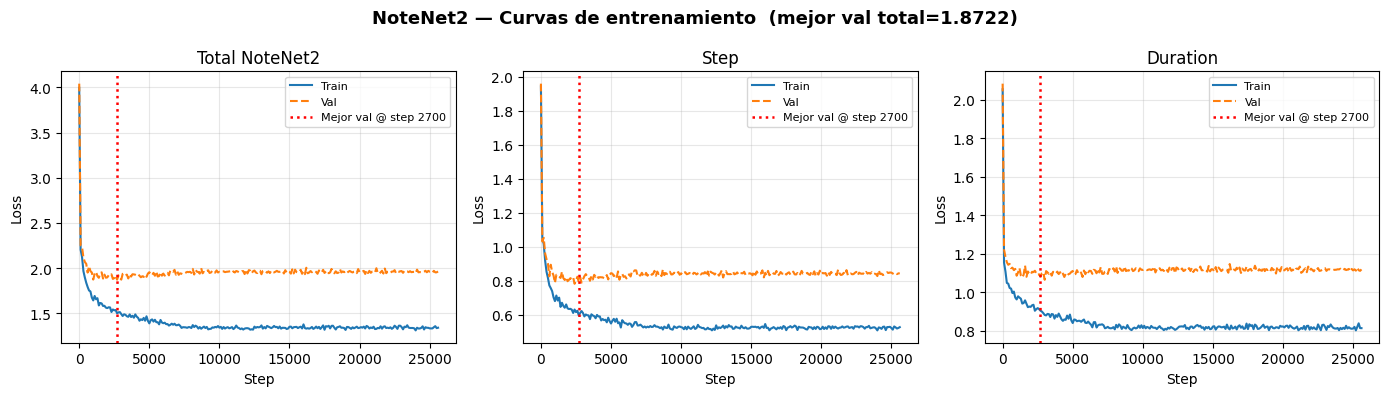

In [35]:
if TRAIN:
    labels2 = {'total2': 'Total NoteNet2', 'step': 'Step', 'dur': 'Duration'}
    steps_x = [i * EVAL_EVERY for i in range(len(h2['train_total2']))]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    for ax, key in zip(axes, LOSS_KEYS_2):
        ax.plot(steps_x, h2[f'train_{key}'], label='Train')
        ax.plot(steps_x, h2[f'val_{key}'],   label='Val', linestyle='--')
        ax.axvline(best_step_2, color='red', linestyle=':', linewidth=1.8,
                label=f'Mejor val @ step {best_step_2}')
        ax.set_title(labels2[key]); ax.set_xlabel('Step'); ax.set_ylabel('Loss')
        ax.legend(fontsize=8); ax.grid(True, alpha=0.3)
    fig.suptitle(f'NoteNet2 — Curvas de entrenamiento  (mejor val total={best_val_2:.4f})',
                fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.show()


En general, el entrenamiento de **NoteNet2** fue estable en sus primeras etapas, mostrando una rápida reducción de la pérdida tanto en entrenamiento como en validación. Sin embargo, a medida que avanzan los pasos, se empieza a observar una separación clara entre ambas curvas, lo que indica la aparición de cierto *overfitting*. Esto se refleja en que la pérdida de entrenamiento sigue disminuyendo mientras que la de validación se estanca.

El uso de *early stopping* fue clave en este caso, ya que permitió detener el entrenamiento en el punto donde la red alcanzó su mejor desempeño en validación (alrededor del paso 2700), evitando un deterioro mayor en la capacidad de generalización.

Al comparar la *Perplexity* de validación con el peor caso posible, se observa una mejora significativa en ambas variables:

- *step*: pasó de aproximadamente **7.1** al inicio a **2.2** en su mejor punto de validación.
- *duration*: pasó de aproximadamente **8.0** a **2.9**.

Esto indica que el modelo logró reducir considerablemente su incertidumbre al predecir el ritmo de la nota. En particular, la variable *step* fue aprendida con mayor precisión, mientras que *duration* resultó un poco más difícil, aunque también mostró una mejora clara.

En conclusión, **NoteNet2** sí logra aprender patrones rítmicos relevantes, pero tiende a sobreajustarse más rápido que **NoteNet1**, por lo que el uso de *early stopping* es fundamental para obtener un buen desempeño en validación. 

Como proximos pasos, se podrian aplicar técnicas de reduccion de *overfitting* como regularización adicional o ajustes en la arquitectura. Asimismo, sería útil revisar y posiblemente mejorar la representación de los datos de entrada, con el fin de facilitar el aprendizaje y mejorar la capacidad de generalización del modelo.

<a id='sec9'></a>
# 9. Cargar modelo

Se carga el checkpoint guardado al final del entrenamiento. Esto permite realizar inferencia en cualquier momento sin necesidad de reentrenar.


<a id='sec91'></a>
## 9.1 Cargar checkpoint

Se reconstruyen `NoteNet1` y `NoteNet2` con los hiperparámetros guardados y se cargan los pesos entrenados.


In [ ]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

if COLAB:
    CKPT_PATH = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1/beethoven_dual_lstm.pt'
else:
    CKPT_PATH = 'Models/beethoven_dual_lstm.pt'


ck = torch.load(CKPT_PATH, map_location=device, weights_only=False)

# Restaurar hiperparámetros de arquitectura
PITCH_CLASS_VOCAB = ck['PITCH_CLASS_VOCAB']
OCTAVE_VOCAB      = ck['OCTAVE_VOCAB']
N_BINS            = ck['N_BINS']
HIDDEN_DIM        = ck['HIDDEN_DIM']
LSTM_LAYERS       = ck['LSTM_LAYERS']
DROPOUT           = ck['DROPOUT']
EMB_PITCH         = ck['EMB_PITCH']
EMB_OCTAVE        = ck['EMB_OCTAVE']
EMB_STEP          = ck['EMB_STEP']
EMB_DUR           = ck['EMB_DUR']
BLOCK_SIZE        = ck['BLOCK_SIZE']

INPUT_DIM_1 = EMB_PITCH + EMB_OCTAVE
INPUT_DIM_2 = EMB_PITCH + EMB_OCTAVE + EMB_STEP + EMB_DUR

class NoteNet1(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.emb_pitch  = nn.Embedding(PITCH_CLASS_VOCAB, EMB_PITCH)
        self.emb_octave = nn.Embedding(OCTAVE_VOCAB, EMB_OCTAVE)

        self.lstm = nn.LSTM(
            INPUT_DIM_1, HIDDEN_DIM, LSTM_LAYERS,
            batch_first=True, dropout=DROPOUT
        )

        # Cabeza MLP para pitch
        self.head_pitch = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 256),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(256, PITCH_CLASS_VOCAB)
        )

        # Cabeza MLP para octave
        self.head_octave = nn.Sequential(
            nn.Linear(HIDDEN_DIM, 128),
            nn.ReLU(),
            nn.Dropout(DROPOUT),
            nn.Linear(128, OCTAVE_VOCAB)
        )

    def forward(self, x):
        # x: (batch, seq, 2) — solo [pitch_class, octave]
        pc   = x[:, :, 0].long()
        oct_ = x[:, :, 1].long()

        emb = torch.cat([self.emb_pitch(pc), self.emb_octave(oct_)], dim=-1)

        h = self.lstm(emb)[0][:, -1, :]   # (batch, HIDDEN_DIM)

        return {
            'pitch': self.head_pitch(h),
            'octave': self.head_octave(h)
        }


net1 = NoteNet1()


class NoteNet2(nn.Module):
    
    def __init__(self):
        super().__init__()
        self.emb_pitch  = nn.Embedding(PITCH_CLASS_VOCAB, EMB_PITCH)
        self.emb_octave = nn.Embedding(OCTAVE_VOCAB,      EMB_OCTAVE)
        self.emb_step   = nn.Embedding(N_BINS,            EMB_STEP)
        self.emb_dur    = nn.Embedding(N_BINS,            EMB_DUR)
        self.lstm = nn.LSTM(INPUT_DIM_2, HIDDEN_DIM, LSTM_LAYERS,
                            batch_first=True, dropout=DROPOUT)
        self.head_step = nn.Linear(HIDDEN_DIM, N_BINS)
        self.head_dur  = nn.Linear(HIDDEN_DIM, N_BINS)

    def forward(self, x):
        pc   = x[:, :, 0].long()
        oct_ = x[:, :, 1].long()
        st   = x[:, :, 2].long()
        dur  = x[:, :, 3].long()
        emb  = torch.cat([self.emb_pitch(pc), self.emb_octave(oct_),
                          self.emb_step(st),  self.emb_dur(dur)], dim=-1)
        h = self.lstm(emb)[0][:, -1, :]
        return {'step': self.head_step(h), 'dur': self.head_dur(h)}


net2 = NoteNet2()

# Reconstruir redes y cargar pesos
net1 = NoteNet1().to(device)
net2 = NoteNet2().to(device)
net1.load_state_dict(ck['net1_state_dict'])
net2.load_state_dict(ck['net2_state_dict'])
net1.eval()
net2.eval()

# Restaurar parámetros de preprocesamiento
params = ck['params']

print(f'Modelo cargado desde: {CKPT_PATH}')
print(f'NoteNet1 parámetros: {sum(p.nelement() for p in net1.parameters()):,}')
print(f'NoteNet2 parámetros: {sum(p.nelement() for p in net2.parameters()):,}')


NoteNet1 parámetros: 3,487,223
NoteNet2 parámetros: 3,318,608
Modelo cargado desde: Models/beethoven_dual_lstm.pt
NoteNet1 parámetros: 3,487,223
NoteNet2 parámetros: 3,318,608


<a id='sec10_eval'></a>
# 10. Evaluación con datos reales (*Test*)

En esta sección se genera música a partir de las canciones del conjunto de test, utilizando la generación baseline por temperatura. Se evalúa la calidad de la generación comparando las distribuciones de las variables generadas con las reales.


<a id='sec10_1'></a>
## 10.1 Selección de semilla

Se toman las primeras `BLOCK_SIZE` notas de una canción del conjunto de test como contexto inicial.


In [ ]:
test_songs_seeds = []

print('Canciones de test disponibles:')
for i, (name, song_df) in enumerate(df_test_t.groupby('song_name', sort=False)):
    song_df = song_df.reset_index(drop=True)
    print(f'  [{i}] {name}  ({len(song_df)} notas)')
    seed = song_df[['pitch_class', 'octave', 'step_bin', 'dur_bin']].head(BLOCK_SIZE).values.tolist()
    test_songs_seeds.append((name, seed))

Canciones de test disponibles:
  [0] beethoven_les_adieux_2.mid  (868 notas)
  [1] beethoven_opus22_2.mid  (2191 notas)
  [2] elise.mid  (1041 notas)


<a id='sec10_2'></a>
## 10.2 Constantes y función de generación junto con función para graficar las distribuciones reales y generadas

Se define la temperatura de muestreo `TEMP` y la función `generate`, que realiza generación autoregresiva simple muestreando cada variable de forma independiente.
Ademas, se implementa una función para graficar las distribuciones reales y generadas de cada variable (pitch_class, octave, step_bin, dur_bin) para comparar la calidad de la generación.


In [ ]:
@torch.no_grad()
def generate(net1, net2, seed, n_notes=200, temperature=1.0):

    # Modo evaluación: desactiva dropout para inferencia reproducible
    net1.eval(); net2.eval()

    # Contexto inicial: últimas BLOCK_SIZE notas de la semilla
    ctx = list(seed[-BLOCK_SIZE:])
    gen = []

    for _ in range(n_notes):
        # Construir tensor de entrada con el contexto actual (BLOCK_SIZE notas)
        x = torch.tensor([ctx[-BLOCK_SIZE:]], dtype=torch.float32).to(device)


        # NoteNet1 predice pitch_class y octave. x[:, :, :2] son las dos primeras columnas (pitch_class, octave)
        out1      = net1(x[:, :, :2])
        probs_pc  = torch.softmax(out1['pitch'][0]  / temperature, dim=-1)
        probs_oct = torch.softmax(out1['octave'][0] / temperature, dim=-1)

        # Muestreo independiente con temperatura para pitch_class y octave
        pc_bin    = torch.multinomial(probs_pc,  1).item()
        oct_bin   = torch.multinomial(probs_oct, 1).item()



        # NoteNet2 predice step y duration. x son las cuatro columnas (pitch_class, octave, step_bin, dur_bin)
        out2      = net2(x)
        probs_st  = torch.softmax(out2['step'][0] / temperature, dim=-1)
        probs_du  = torch.softmax(out2['dur'][0]  / temperature, dim=-1)

        # Muestreo independiente con temperatura para step_bin y dur_bin
        step_bin  = torch.multinomial(probs_st, 1).item()
        dur_bin   = torch.multinomial(probs_du, 1).item()

        # Agregar nota al contexto (autoregresivo) y a la lista de salida
        ctx.append([pc_bin, oct_bin, step_bin, dur_bin])
        gen.append({'pitch_class': pc_bin, 'octave': oct_bin,
                    'step_bin': step_bin,  'dur_bin': dur_bin,
                    'velocity': 51})  # velocity fija en la media del dataset
    return gen



def compare_real_gen(gen_notes_base, seed_beethoven, song_df):
    n_seed, n_gen = BLOCK_SIZE, len(gen_notes_base)
    idx_real = np.arange(n_seed + n_gen)
    idx_seed = np.arange(n_seed)
    idx_gen  = np.arange(n_seed, n_seed + n_gen)

    real_all = song_df.iloc[:n_seed + n_gen].reset_index(drop=True)
    real_ref = song_df.iloc[n_seed:n_seed + n_gen].reset_index(drop=True)

    gen_map = {k: np.array([n[k] for n in gen_notes_base])
               for k in ['pitch_class', 'octave', 'step_bin', 'dur_bin']}
    seed_map = dict(zip(['pitch_class', 'octave', 'step_bin', 'dur_bin'],
                        np.array(seed_beethoven).T))

    C_REAL = 'steelblue'
    C_GEN  = 'tomato'

    @torch.no_grad()
    def compute_test_ppl(seqs, n_batches=100):
        net1.eval(); net2.eval()
        loader = MusicDataLoader(seqs, BLOCK_SIZE)
        L = {k: [] for k in ['pitch', 'octave', 'step', 'dur']}
        for _ in range(n_batches):
            x, y = loader.get_batch(BATCH_SIZE)
            x, y = x.to(device), y.to(device)
            o1, o2 = net1(x[:, :, :2]), net2(x)
            L['pitch'].append(F.cross_entropy(o1['pitch'],  y[:, 0].long()).item())
            L['octave'].append(F.cross_entropy(o1['octave'], y[:, 1].long()).item())
            L['step'].append(F.cross_entropy(o2['step'],    y[:, 2].long()).item())
            L['dur'].append(F.cross_entropy(o2['dur'],      y[:, 3].long()).item())
        return {k: math.exp(np.mean(v)) for k, v in L.items()}

    ppl = compute_test_ppl(test_seqs)
    ppl_map = dict(zip(
        ['pitch_class', 'octave', 'step_bin', 'dur_bin'],
        [ppl['pitch'], ppl['octave'], ppl['step'], ppl['dur']]
    ))

    features = [
        ('pitch_class', range(12), ['C','C#','D','D#','E','F','F#','G','G#','A','A#','B'], (-0.5, 11.5)),
        ('octave', range(OCTAVE_VOCAB), [f'oct {i-1}' for i in range(OCTAVE_VOCAB)], (-0.5, OCTAVE_VOCAB - 0.5)),
        ('step_bin', range(N_BINS), [f'bin {i}' for i in range(N_BINS)], (-0.5, N_BINS - 0.5)),
        ('dur_bin', range(N_BINS), [f'bin {i}' for i in range(N_BINS)], (-0.5, N_BINS - 0.5)),
    ]

    for name, yticks, ylabels, ylim in features:
        gen  = gen_map[name]
        seed = seed_map[name]
        real = real_all[name].values
        ref  = real_ref[name].values

        fig, ax = plt.subplots(4, 1, figsize=(16, 14))
        fig.suptitle(f'{name} | ppl = {ppl_map[name]:.3f}', fontweight='bold')

        # 1) Real completo
        for i, vals, a in [(idx_real[:n_seed], real[:n_seed], 0.5),
                           (idx_real[n_seed:], real[n_seed:], 0.9)]:
            ax[0].scatter(i, vals, s=5, color=C_REAL, alpha=a)
            ax[0].step(i, vals, where='post', color=C_REAL, alpha=0.3)

        ax[0].set(
            title='Secuencia real',
            xlabel='Índice de nota',
            ylabel=name,
            yticks=list(yticks),
            yticklabels=ylabels,
            ylim=ylim
        )
        ax[0].legend(handles=[
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_REAL, markersize=7, label='Real'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_GEN,  markersize=7, label='Generado / semilla')
        ], loc='upper right')

        # 2) Semilla + generado
        for i, vals, c in [(idx_seed, seed, C_REAL), (idx_gen, gen, C_GEN)]:
            ax[1].scatter(i, vals, s=5, color=c)
            ax[1].step(i, vals, where='post', color=c, alpha=0.3)

        ax[1].set(
            title='Semilla real + continuación generada',
            xlabel='Índice de nota',
            ylabel=name,
            yticks=list(yticks),
            yticklabels=ylabels,
            ylim=ylim
        )
        ax[1].legend(handles=[
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_REAL, markersize=7, label='Semilla real'),
            plt.Line2D([0], [0], marker='o', color='w', markerfacecolor=C_GEN,  markersize=7, label='Generado')
        ], loc='upper right')

        # 3) Distribución
        edges = np.arange(ylim[0], ylim[1] + 1, 1)
        pr = np.histogram(ref, bins=edges)[0].astype(float)
        pg = np.histogram(gen, bins=edges)[0].astype(float)
        pr /= pr.sum()
        pg /= pg.sum()
        centers = (edges[:-1] + edges[1:]) / 2
        js = jensenshannon(pr, pg)

        ax[2].bar(centers - 0.2, pr * 100, 0.4, color=C_REAL, label='Real')
        ax[2].bar(centers + 0.2, pg * 100, 0.4, color=C_GEN,  label='Generado')
        ax[2].set(
            title='Distribución real vs generada',
            xlabel=name,
            ylabel='Porcentaje (%)',
            xticks=list(centers),
            xticklabels=ylabels,
            xlim=ylim
        )
        ax[2].legend(loc='upper left')
        ax[2].text(
            0.98, 0.95,
            f'JS = {js:.4f}\nPerplexity = {ppl_map[name]:.3f}',
            transform=ax[2].transAxes,
            ha='left', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

        # 4) Distribución generada vs distribución de train (antes de augmentación)
        df_train_orig = apply_params(df_train, params)
        train_vals = df_train_orig[name].values
        pt = np.histogram(train_vals, bins=edges)[0].astype(float)
        pt /= pt.sum()
        js_train = jensenshannon(pt, pg)

        ax[3].bar(centers - 0.2, pt * 100, 0.4, color='forestgreen', label='Train')
        ax[3].bar(centers + 0.2, pg * 100, 0.4, color=C_GEN,          label='Generado')
        ax[3].set(
            title='Distribución Train vs Generado',
            xlabel=name,
            ylabel='% de notas',
            xticks=list(centers),
            xticklabels=ylabels,
            xlim=ylim
        )
        ax[3].legend(loc='upper left')
        ax[3].text(
            0.98, 0.95,
            f'JS(train||gen) = {js_train:.4f}',
            transform=ax[3].transAxes,
            ha='right', va='top',
            fontsize=9,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8)
        )

        for a in ax:
            a.grid(True, alpha=0.3)

        plt.tight_layout()
        plt.show()

<a id='sec10_3'></a>
## 10.3 Ejecución — generación baseline

Se genera una secuencia de 200 notas a partir de la semilla seleccionada, utilizando una temperatura `TEMP`. A partir de esta generación, se compara el comportamiento del modelo frente a la secuencia real correspondiente del conjunto de test.

Para cada *feature* se muestran tres gráficas: la secuencia real, la secuencia generada a partir de la semilla y la comparación de distribuciones entre valores reales y generados. Además, se reportan métricas como la *Perplexity* y la divergencia de *Jensen-Shannon (JS)*.

Adicionalmente, se incluye la comparación entre la distribución generada y la distribución global del conjunto de entrenamiento antes de la aumentación. Esto permite evaluar el comportamiento del modelo no solo frente a una única canción (lo cual puede ser una comparación sesgada o poco representativa), sino frente al estilo general aprendido de Beethoven en el conjunto de entrenamiento.

La divergencia de *Jensen-Shannon* se utiliza para comparar distribuciones de probabilidad de manera simétrica y estable. En este contexto, permite evaluar qué tan parecida es la distribución de notas generadas respecto a la distribución real. Un valor de *JS* cercano a 0 indica que ambas distribuciones son muy similares, mientras que valores más altos indican mayor diferencia. Por tanto, un valor bajo de *JS* sugiere que el modelo está logrando reproducir de forma razonable el estilo estadístico presente en la música de Beethoven, al menos en términos de distribución de las variables generadas.

Por otro lado, también se analiza la *Perplexity*, calculada de forma independiente para cada *feature*. Esta métrica indica qué tan segura o incierta está la red al momento de predecir la siguiente categoría. En general, entre menor sea la *Perplexity*, mejor es el desempeño del modelo, ya que significa que el modelo duda entre menos opciones al generar la siguiente nota.

Sin embargo, como se explicó en la Sección 6.2, la interpretación de esta métrica depende del número de categorías de cada variable. En el peor caso, cuando el modelo no ha aprendido nada y asigna probabilidades uniformes, la *Perplexity* coincide con el número de clases posibles. Por tanto, los peores valores esperados son:

- **12** para *pitch_class*
- **11** para *octave*
- **8** para *step_bin*
- **8** para *dur_bin*

Así, una *Perplexity* significativamente inferior a estos valores indica que el modelo ha aprendido patrones útiles y que sus predicciones son mejores que una asignación aleatoria uniforme.

Canción: beethoven_les_adieux_2.mid


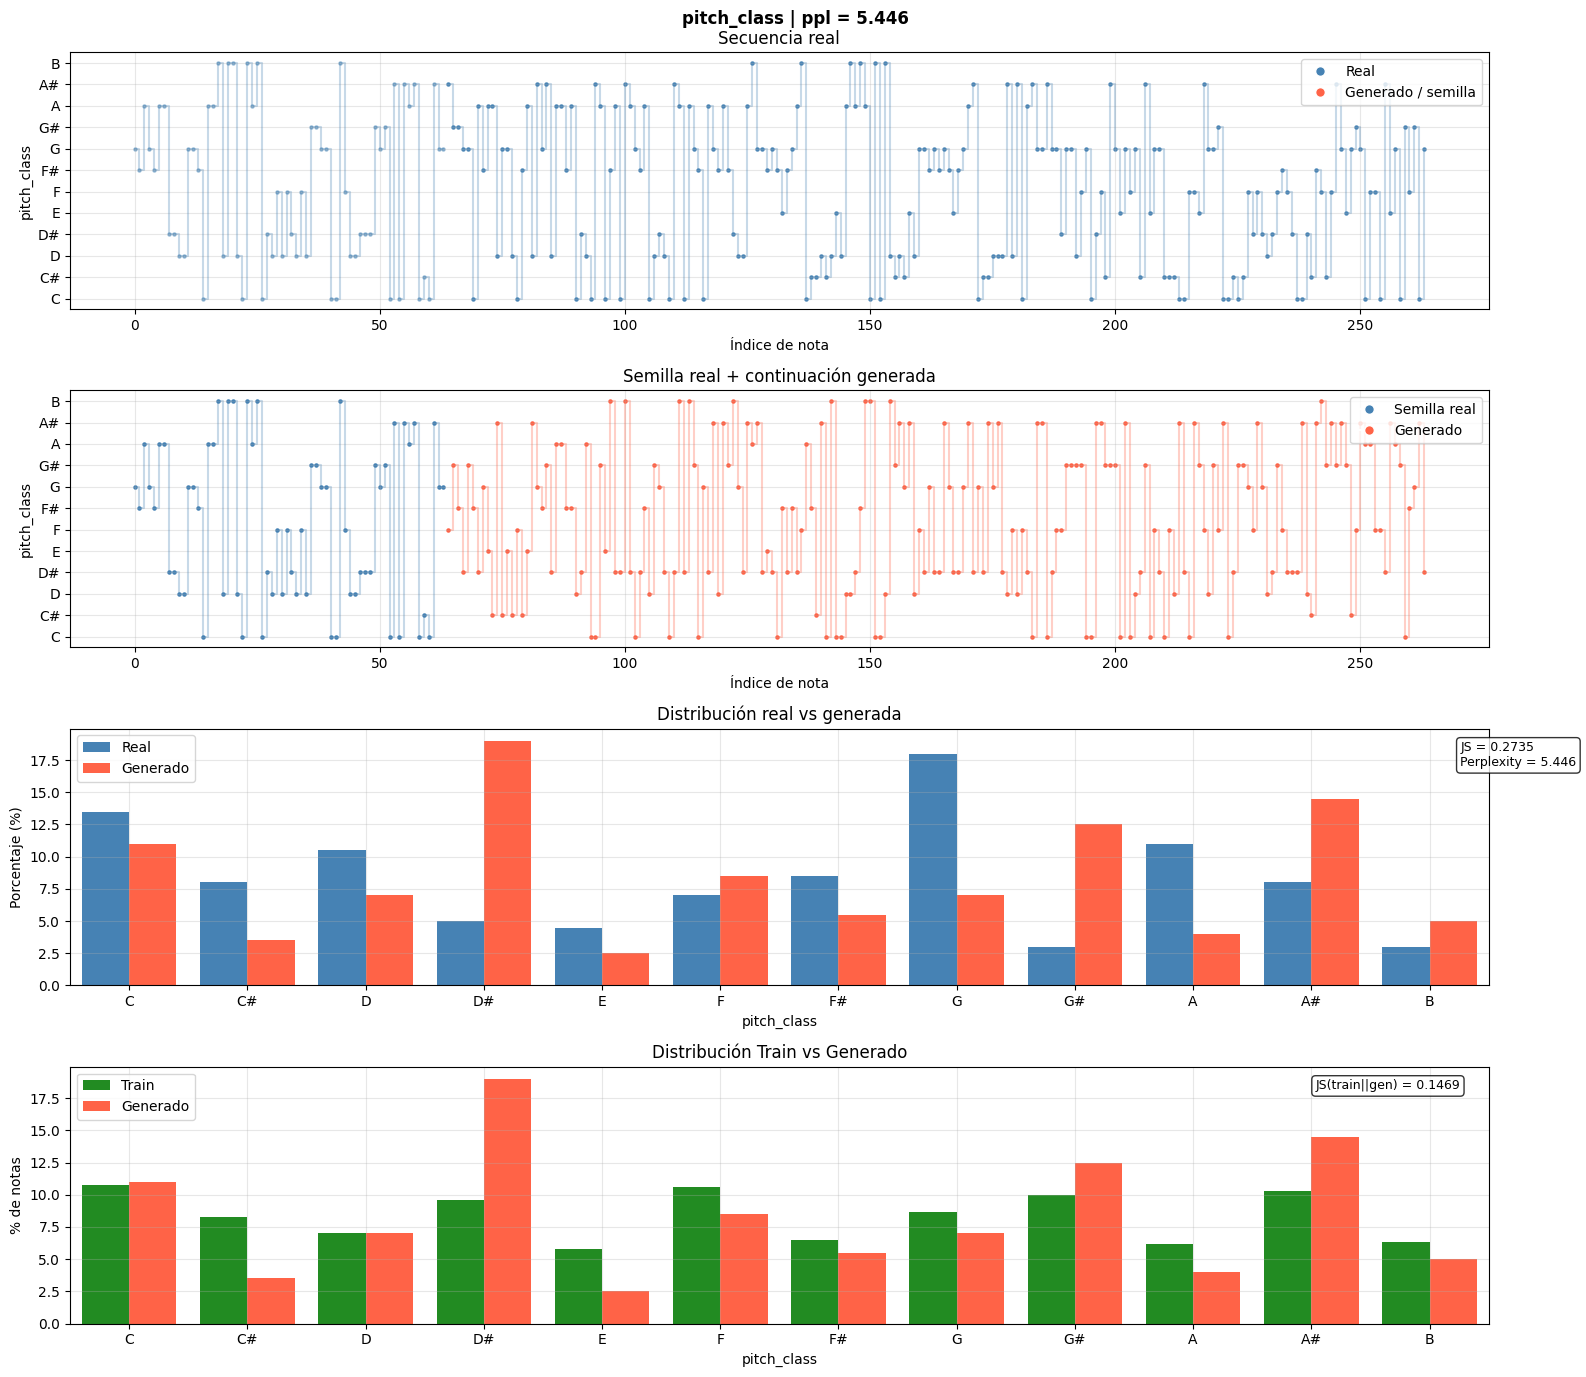

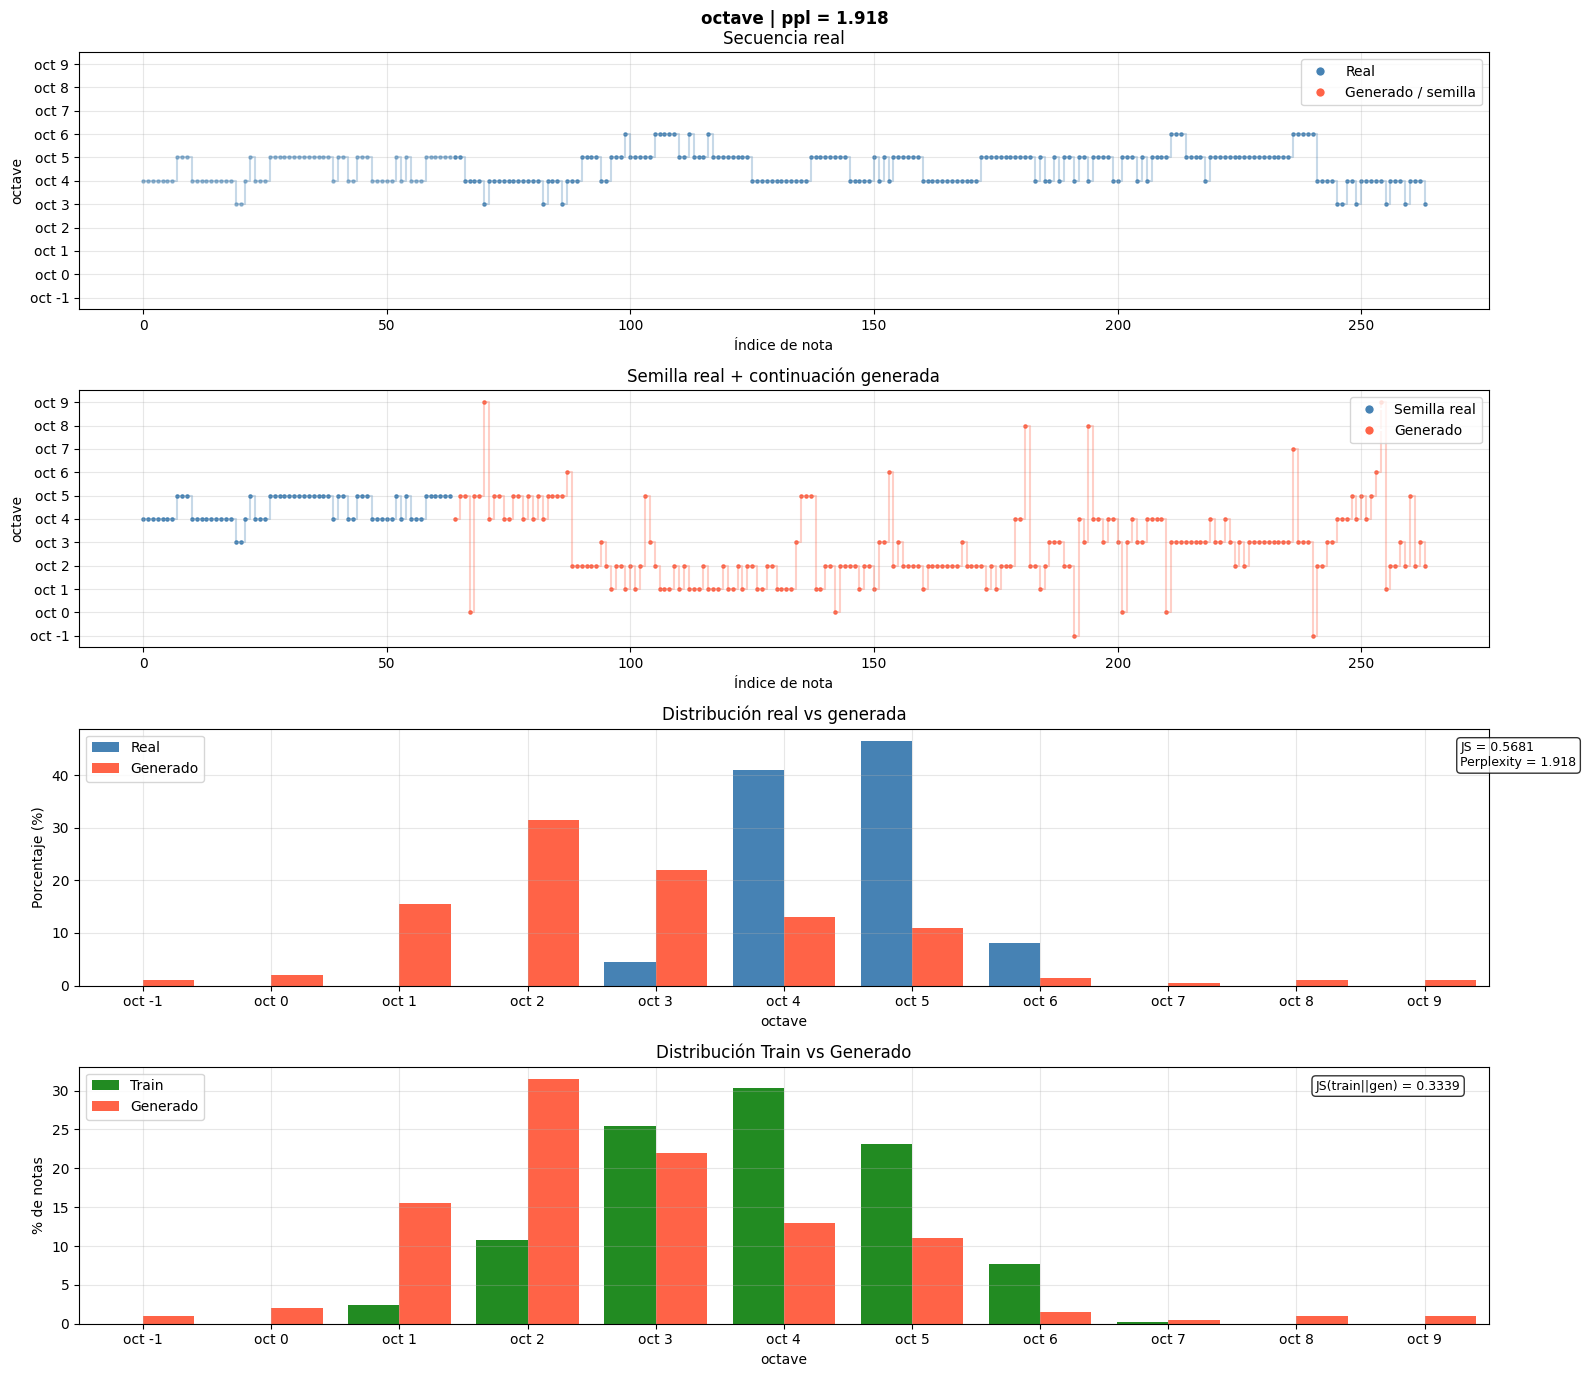

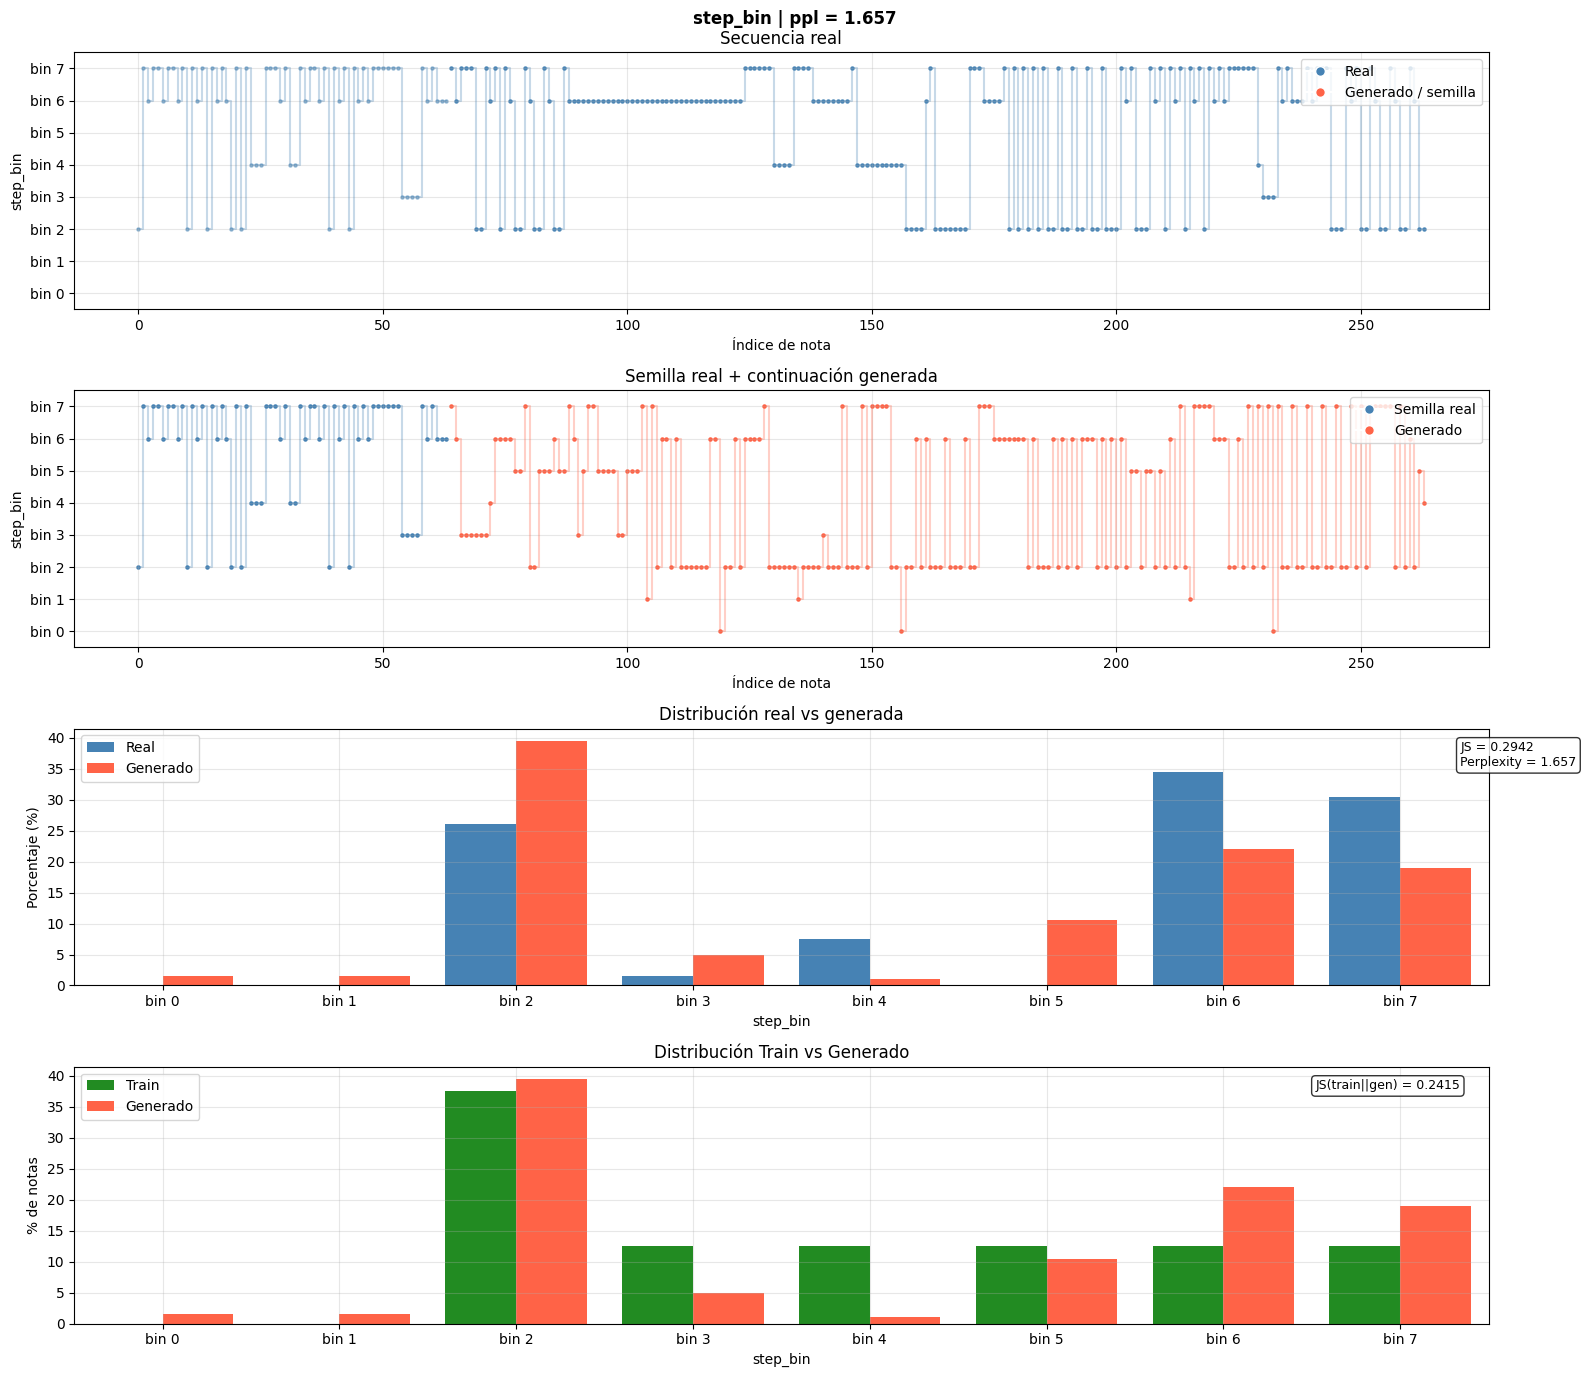

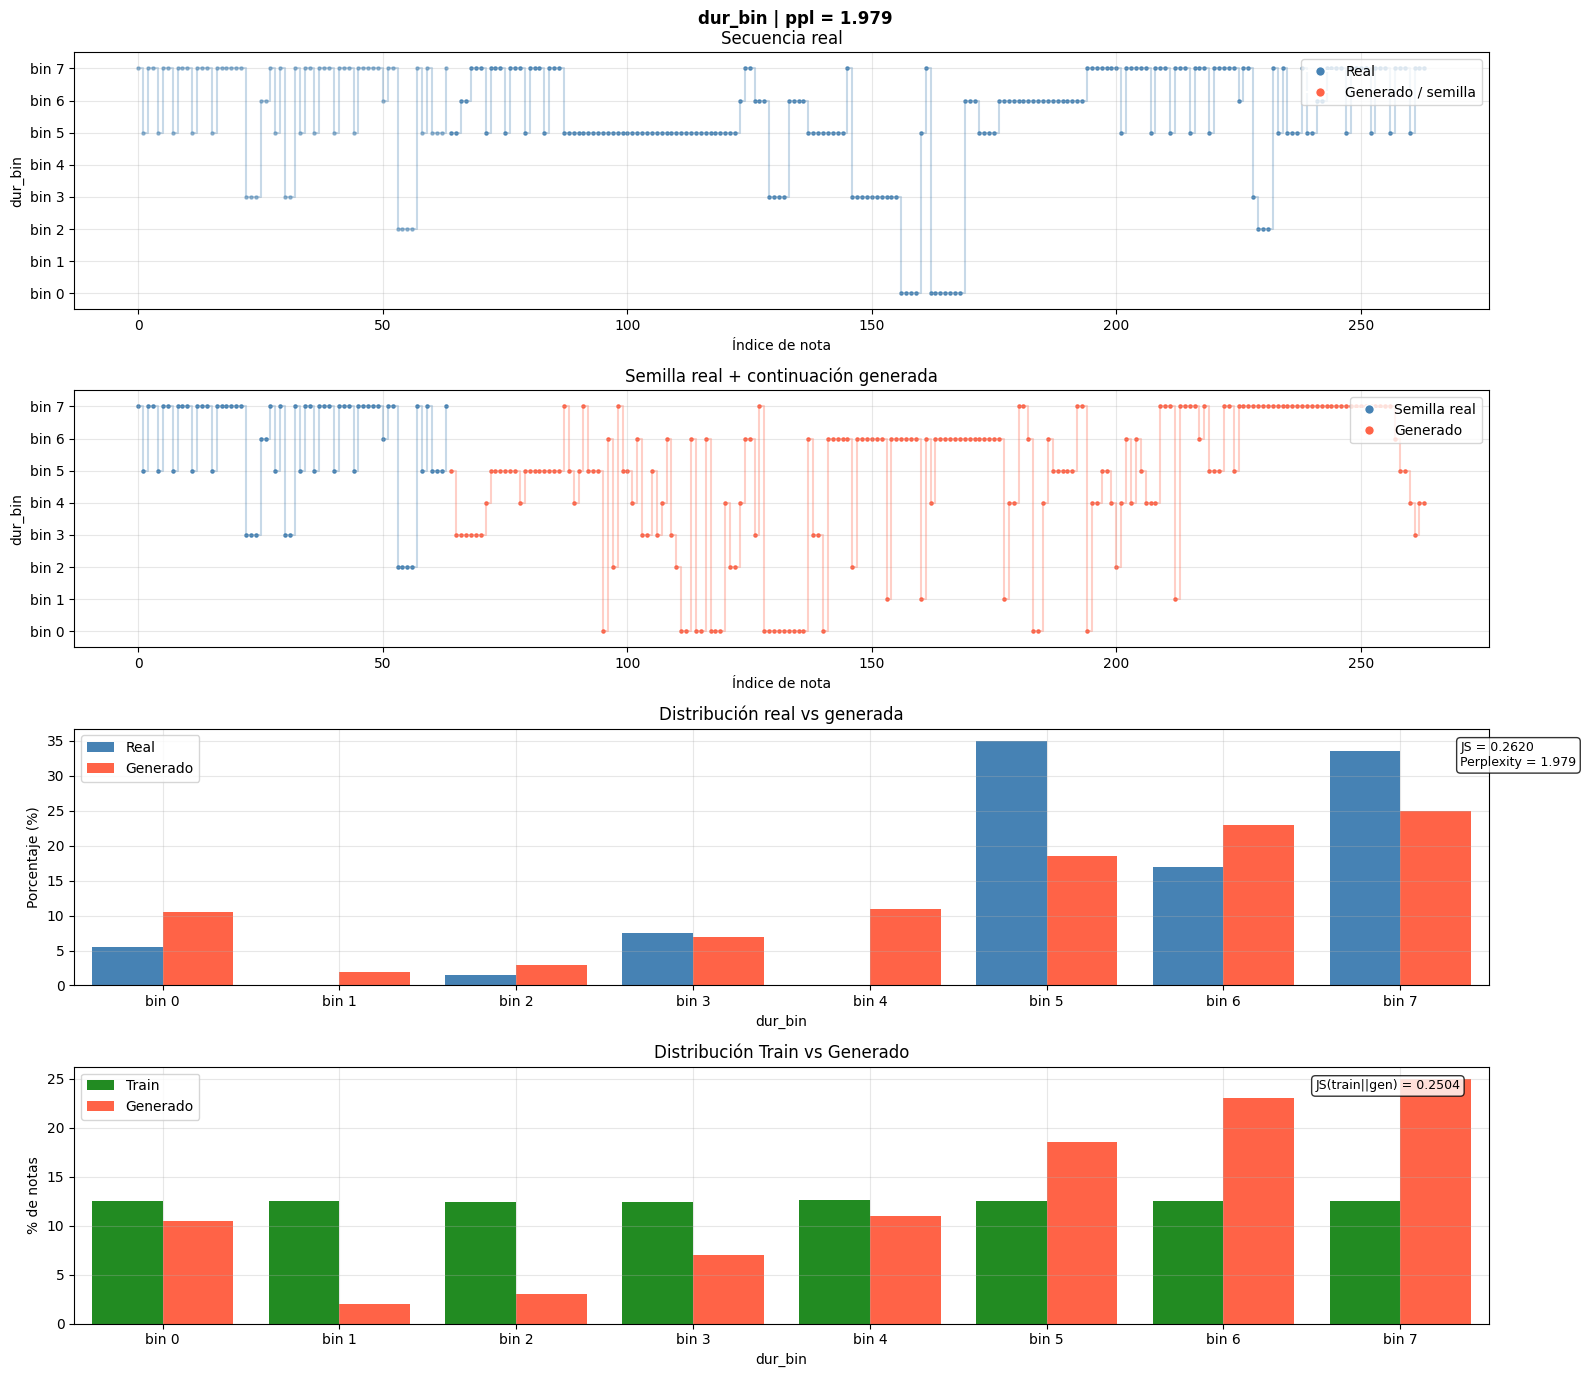

In [ ]:
one_song = True # Si True, solo se evalúa la primera canción de test (más rápida para iterar). Si False, se evalúan todas las canciones de test disponibles.

if one_song:
    test_songs_seeds = [test_songs_seeds[0]]

for song_name, seed_beethoven in test_songs_seeds:
    print("=" * 60)
    print(f"Canción: {song_name}")
    song_df = df_test_t[df_test_t['song_name'] == song_name].reset_index(drop=True)
    gen_notes_base = generate(net1, net2, seed_beethoven, n_notes=200, temperature=TEMP)
    compare_real_gen(gen_notes_base, seed_beethoven, song_df)


## 10.4 Conclusiones — análisis sobre una canción de test

El análisis de la secuencia generada frente a la real, evaluado mediante *Perplexity* y divergencia de Jensen-Shannon (JS), muestra que el modelo presenta un comportamiento desigual según la variable. Es importante destacar que, para la interpretación principal, se utiliza la divergencia JS entre la distribución generada y la distribución del conjunto de entrenamiento (*JS(train || gen)*), ya que esta comparación permite evaluar qué tan bien el modelo reproduce el estilo global de Beethoven, más allá de una sola canción del conjunto de test.

En *pitch_class*, la *Perplexity* (~5.45) confirma que sigue siendo la tarea más difícil, mientras que la JS (~0.15 respecto a train) indica que el modelo logra capturar de manera razonable la distribución tonal global, aunque sin reproducir con precisión la progresión armónica específica de la pieza.

En *octave*, se observa una *Perplexity* baja (~1.92), lo que sugiere alta confianza, pero una JS moderada (~0.33 respecto a train), evidenciando que, aunque el modelo es relativamente consistente, aún presenta un sesgo en la distribución de alturas y no replica completamente el rango tonal real.

Por otro lado, en *step* y *duration* se obtienen *Perplexity* bajas (~1.66 y ~1.98) y valores de JS moderados (~0.24 y ~0.25 respecto a train), lo que indica que el modelo captura parcialmente la estructura rítmica y las duraciones, aunque con desviaciones respecto a la distribución real, especialmente en la frecuencia de ciertos patrones.

En conjunto, el modelo logra reproducir de forma aceptable algunos patrones estadísticos globales del estilo, particularmente en la distribución tonal, pero presenta limitaciones en la modelación precisa del rango tonal y de la estructura rítmica, evidenciando que aún no captura completamente las dependencias musicales más complejas. Asimismo, se confirma que una baja *Perplexity* no garantiza una buena representación de la distribución real, por lo que es fundamental complementar esta métrica con medidas de similitud de distribución como la divergencia de Jensen-Shannon.

**Nota: Los valores reportados pueden variar entre ejecuciones, ya que el modelo es estocástico y genera las notas a partir de distribuciones de probabilidad. Pequeñas variaciones en una predicción inicial pueden propagarse y generar secuencias completamente diferentes, afectando tanto la secuencia generada como las métricas asociadas.**

<a id='sec11'></a>
# 11. Generación con restricciones musicales

Los resultados de la generación baseline son razonables pero muestran desviaciones
en *pitch_class* y *octave* respecto a las distribuciones reales. Para corregirlo se
incorporan **restricciones suaves** que actúan directamente sobre los logits antes del
muestreo, sin modificar ni reentrenar el modelo.

| Restricción | Descripción |
|---|---|
| **Repetition penalty** | Penaliza notas que aparecieron en las últimas `k` posiciones |
| **Jump penalty** | Penaliza saltos > quinta (7 st) y > octava (12 st) |
| **Interval bias** | Favorece intervalos frecuentes en el corpus de entrenamiento |

El flujo de aplicación es:

> *logits del modelo → repetition penalty → jump penalty → interval bias → softmax → muestreo*

<a id='sec11_0'></a>
## 11.0 Constantes y funciones auxiliares

Constantes de audio y grilla rítmica, y las funciones `decode_notes` y `notes_to_midi`
que convierten los tokens generados a notas reales y a formato MIDI.

In [35]:
RHYTHM_GRID = np.array([0.0, 0.125, 0.25, 0.333, 0.5, 0.667, 0.75, 1.0, 1.5, 2.0])
SAMPLE_RATE = 22050

def quantize(v):
    """Redondea v al valor más cercano de RHYTHM_GRID."""
    return float(RHYTHM_GRID[np.argmin(np.abs(RHYTHM_GRID - v))])


def decode_notes(gen_notes, params):
    """Convierte tokens generados a dicts {pitch, step, duration, velocity}."""
    step_mids = (params['step_edges'][:-1] + params['step_edges'][1:]) / 2
    dur_mids  = (params['dur_edges'][:-1]  + params['dur_edges'][1:])  / 2
    rows = []
    for n in gen_notes:
        pitch    = int(np.clip(n['octave'] * 12 + n['pitch_class'], 0, 127))
        step     = quantize(float(np.expm1(step_mids[n['step_bin']])))
        duration = max(quantize(float(np.expm1(dur_mids[n['dur_bin']]))), 0.125)
        rows.append({'pitch': pitch, 'step': step, 'duration': duration, 'velocity': n['velocity']})
    return rows


def notes_to_midi(notes, instrument_name='Acoustic Grand Piano', tempo_scale=1.0):
    """Convierte una lista de notas decodificadas a un objeto PrettyMIDI."""
    pm    = pretty_midi.PrettyMIDI()
    instr = pretty_midi.Instrument(program=pretty_midi.instrument_name_to_program(instrument_name))
    t = 0.0
    for n in notes:
        t  += max(n['step'], 0.0) * tempo_scale
        end = t + max(n['duration'], 0.05) * tempo_scale
        instr.notes.append(pretty_midi.Note(velocity=n['velocity'], pitch=n['pitch'], start=t, end=end))
    pm.instruments.append(instr)
    return pm

<a id='sec11_1'></a>
## 11.1 Distribución de intervalos del corpus

Calcula, sobre el set de entrenamiento, la distribución log-suavizada de intervalos
melódicos consecutivos (en semitonos). Esta distribución se usa luego como prior
empírico en el *interval bias*.

In [ ]:
def compute_interval_distribution(df, min_count=5):
    counts = Counter()
    for _, g in df.groupby(['song_id', 'n_pista']):
        pitch = g['octave'].values * 12 + g['pitch_class'].values
        counts.update(np.diff(pitch.astype(int)))

    counts       = {k: v for k, v in counts.items() if v >= min_count}
    total, vocab = sum(counts.values()), len(counts)
    interval_dist = {k: np.log((v + 1) / (total + vocab)) for k, v in counts.items()}
    return interval_dist, np.log(1 / (total + vocab))

interval_dist, interval_baseline = compute_interval_distribution(df_train_t)
print(f'Intervalos en corpus: {len(interval_dist)}  '
      f'| más frecuente: {max(interval_dist, key=interval_dist.get):+d} st')

Intervalos en corpus: 89  | más frecuente: -2 st


<a id='sec11_2'></a>
## 11.2 Restricciones musicales suaves

Cuatro funciones que operan sobre el tensor de logits conjunto (12, 11) —
una celda por cada combinación (pitch_class, octave):

| Función | Efecto |
|---|---|
| apply_repetition_penalty | Descuenta *log(penalty)* a notas repetidas recientemente |
| apply_jump_penalty | Añade penalización negativa a saltos grandes (vectorizado) |
| apply_interval_bias | Suma el log-score empírico del intervalo candidato |
| apply_musical_constraints | Compone las tres anteriores en secuencia |

In [33]:
def apply_repetition_penalty(joint_logits, recent_pitches_midi,
                             recent_window=8, repeat_penalty=0.8):
    """Descuenta log(repeat_penalty) a los logits de notas vistas en las últimas k posiciones."""
    out, delta = joint_logits.clone(), float(np.log(repeat_penalty))
    for p in recent_pitches_midi[-recent_window:]:
        pc, octv = int(p) % 12, int(p) // 12
        if 0 <= octv < OCTAVE_VOCAB:
            out[pc, octv] += delta
    return out


def apply_jump_penalty(joint_logits, last_pitch_midi,
                       threshold_moderate=7, threshold_strong=12,
                       penalty_moderate=-1.0, penalty_strong=-3.0):
    """Penaliza saltos > quinta (threshold_moderate st) y > octava (threshold_strong st)."""
    pc   = torch.arange(PITCH_CLASS_VOCAB, device=joint_logits.device).view(-1, 1)
    octv = torch.arange(OCTAVE_VOCAB,      device=joint_logits.device).view(1, -1)
    jump = (octv * 12 + pc - int(last_pitch_midi)).abs().float()
    pen  = ((jump > threshold_strong).float() * penalty_strong
          + ((jump > threshold_moderate) & (jump <= threshold_strong)).float() * penalty_moderate)
    return joint_logits + pen


def apply_interval_bias(joint_logits, last_pitch_midi,
                        interval_dist, baseline, bias_strength=0.5):
    """Suma el log-score empírico del intervalo (nota candidata − last_pitch) a cada logit."""
    bias = torch.tensor(
        [[interval_dist.get(octv * 12 + pc - int(last_pitch_midi), baseline)
          for octv in range(OCTAVE_VOCAB)]
         for pc in range(PITCH_CLASS_VOCAB)],
        dtype=torch.float32, device=joint_logits.device)
    return joint_logits + bias_strength * bias


def apply_musical_constraints(joint_logits, last_pitch_midi, recent_pitches_midi,
                              interval_dist, baseline,
                              recent_window=8, repeat_penalty=0.8,
                              threshold_moderate=7, threshold_strong=12,
                              penalty_moderate=-1.0, penalty_strong=-3.0,
                              bias_strength=0.5):
    """Aplica en orden: repetition penalty → jump penalty → interval bias."""
    logits = apply_repetition_penalty(joint_logits, recent_pitches_midi, recent_window, repeat_penalty)
    logits = apply_jump_penalty(logits, last_pitch_midi, threshold_moderate, threshold_strong,
                                penalty_moderate, penalty_strong)
    return apply_interval_bias(logits, last_pitch_midi, interval_dist, baseline, bias_strength)

<a id='sec11_3'></a>
## 11.3 Función de generación con restricciones

`generate_with_constraints` extiende la generación baseline construyendo la
distribución conjunta `(pc, oct)` en **log-space** y aplicando las tres
restricciones antes del muestreo. NoteNet2 y velocity siguen el flujo usual.

In [ ]:
@torch.no_grad()
def generate_with_constraints(net1, net2, seed, interval_dist, baseline,
                               n_notes=200, temperature=1.0,
                               recent_window=8, repeat_penalty=0.8,
                               threshold_moderate=7, threshold_strong=12,
                               penalty_moderate=-1.0, penalty_strong=-3.0,
                               bias_strength=0.5):
    """
    Generación con restricciones musicales suaves sobre NoteNet1.

    Combina log-probs de pitch_class y octave en una distribución conjunta (12, 11),
    aplica repetition penalty → jump penalty → interval bias y muestrea la nota.
    NoteNet2 (step, dur) y velocity no se modifican.
    """
    net1.eval(); net2.eval()
    ctx            = list(seed[-BLOCK_SIZE:])
    recent_pitches = [int(t[1]) * 12 + int(t[0]) for t in ctx[-recent_window:]]
    last_pitch     = recent_pitches[-1] if recent_pitches else 60
    gen = []

    for _ in range(n_notes):
        seq = ctx[-BLOCK_SIZE:]
        if len(seq) < BLOCK_SIZE:
            seq = [[0, 0, 0, 0]] * (BLOCK_SIZE - len(seq)) + seq
        x = torch.tensor([seq], dtype=torch.float32, device=device)

        # NoteNet1: distribución conjunta (pc, oct) + restricciones
        out1  = net1(x[:, :, :2])
        joint = (torch.log_softmax(out1['pitch'][0]  / temperature, dim=-1).unsqueeze(1)
               + torch.log_softmax(out1['octave'][0] / temperature, dim=-1).unsqueeze(0))
        joint = apply_musical_constraints(
            joint, last_pitch, recent_pitches, interval_dist, baseline,
            recent_window, repeat_penalty, threshold_moderate, threshold_strong,
            penalty_moderate, penalty_strong, bias_strength)
        idx             = torch.multinomial(torch.softmax(joint.reshape(-1), dim=-1), 1).item()
        pc_bin, oct_bin = divmod(idx, OCTAVE_VOCAB)

        # NoteNet2: step y duration sin restricciones
        out2     = net2(x)
        step_bin = torch.multinomial(torch.softmax(out2['step'][0] / temperature, dim=-1), 1).item()
        dur_bin  = torch.multinomial(torch.softmax(out2['dur'][0]  / temperature, dim=-1), 1).item()

        last_pitch     = oct_bin * 12 + pc_bin
        recent_pitches = (recent_pitches + [last_pitch])[-recent_window:]
        ctx.append([pc_bin, oct_bin, step_bin, dur_bin])
        gen.append({'pitch_class': pc_bin, 'octave': oct_bin,
                    'step_bin': step_bin,  'dur_bin': dur_bin, 'velocity': 51})

    return gen

<a id='sec11_4'></a>
## 11.4 Generación con reestricciones y comparación con datos reales

Se genera una secuencia de 200 notas con restricciones a partir de la semilla de test
y se compara con la secuencia real usando `compare_real_gen`.

Canción: beethoven_les_adieux_2.mid


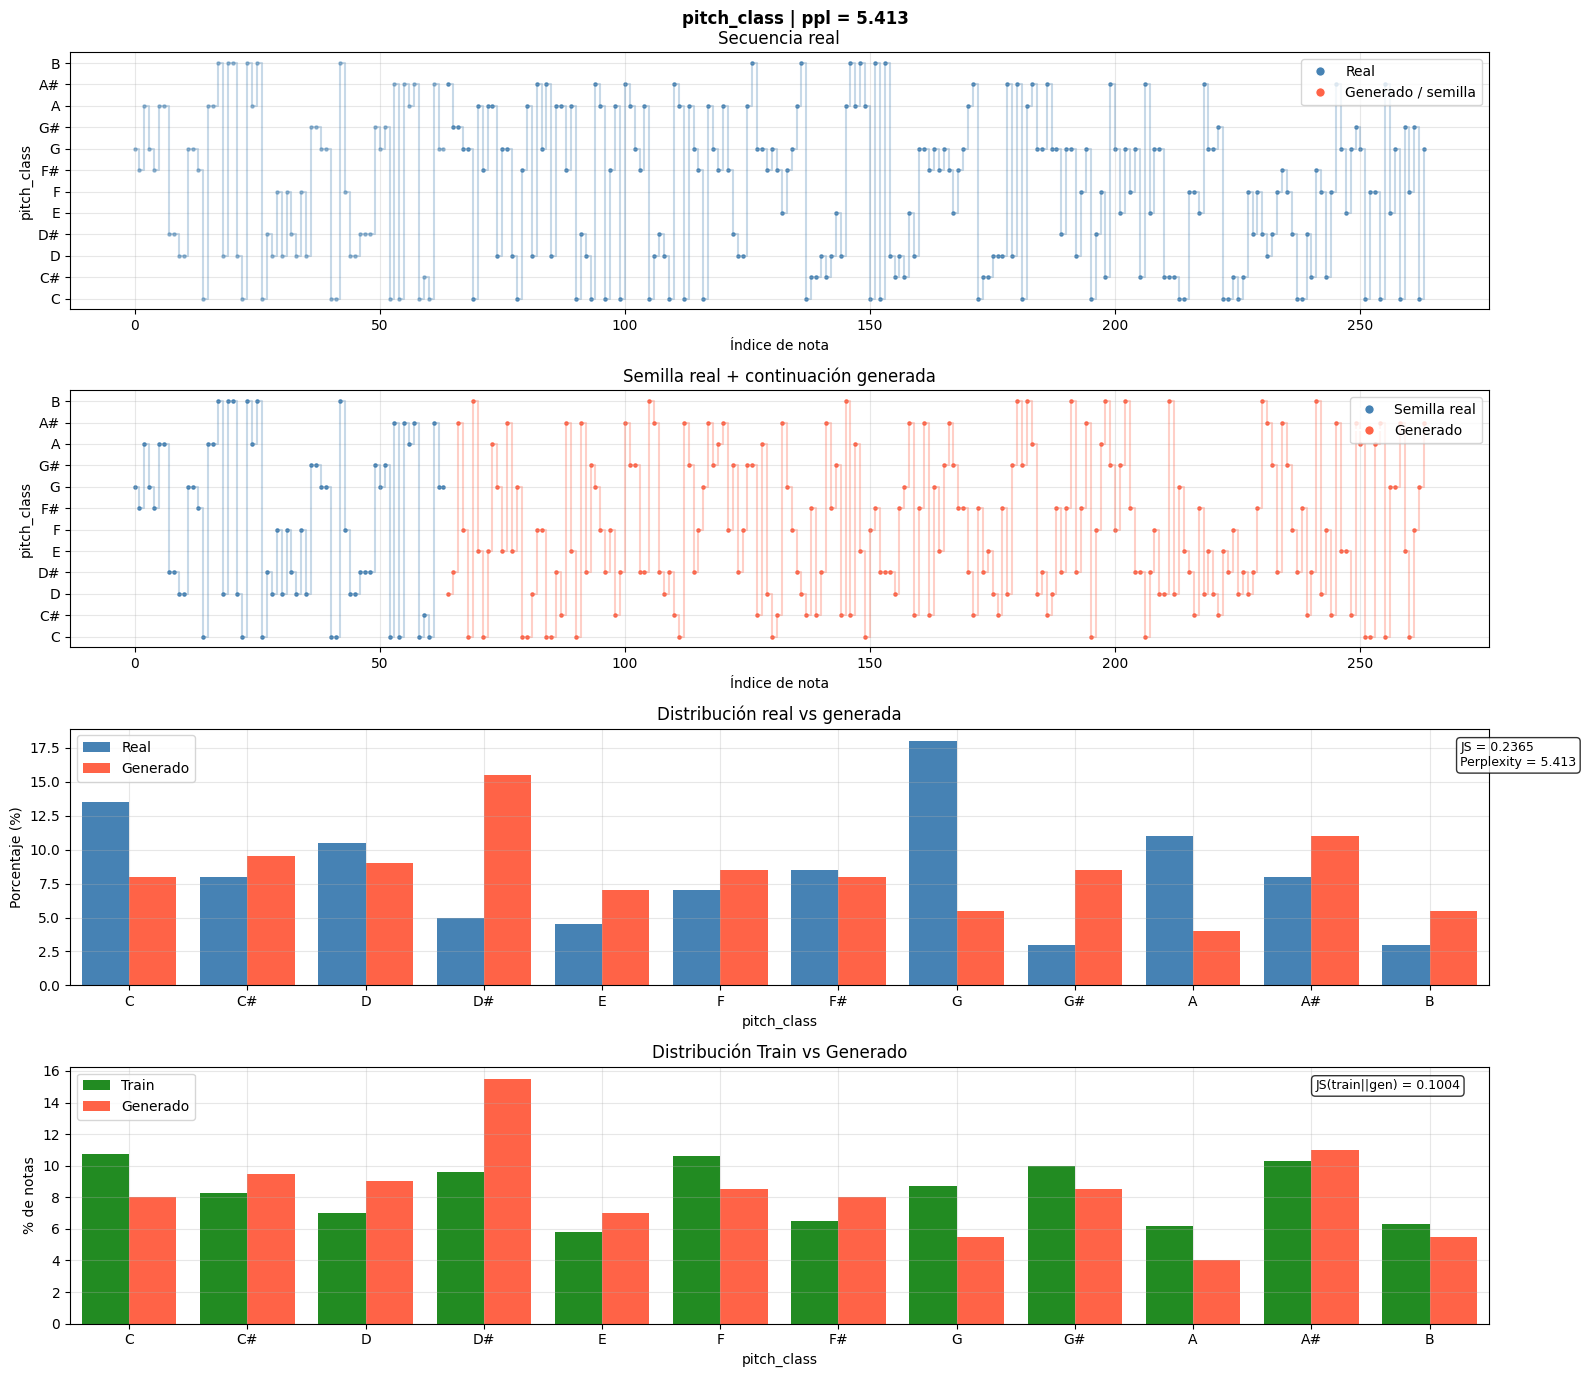

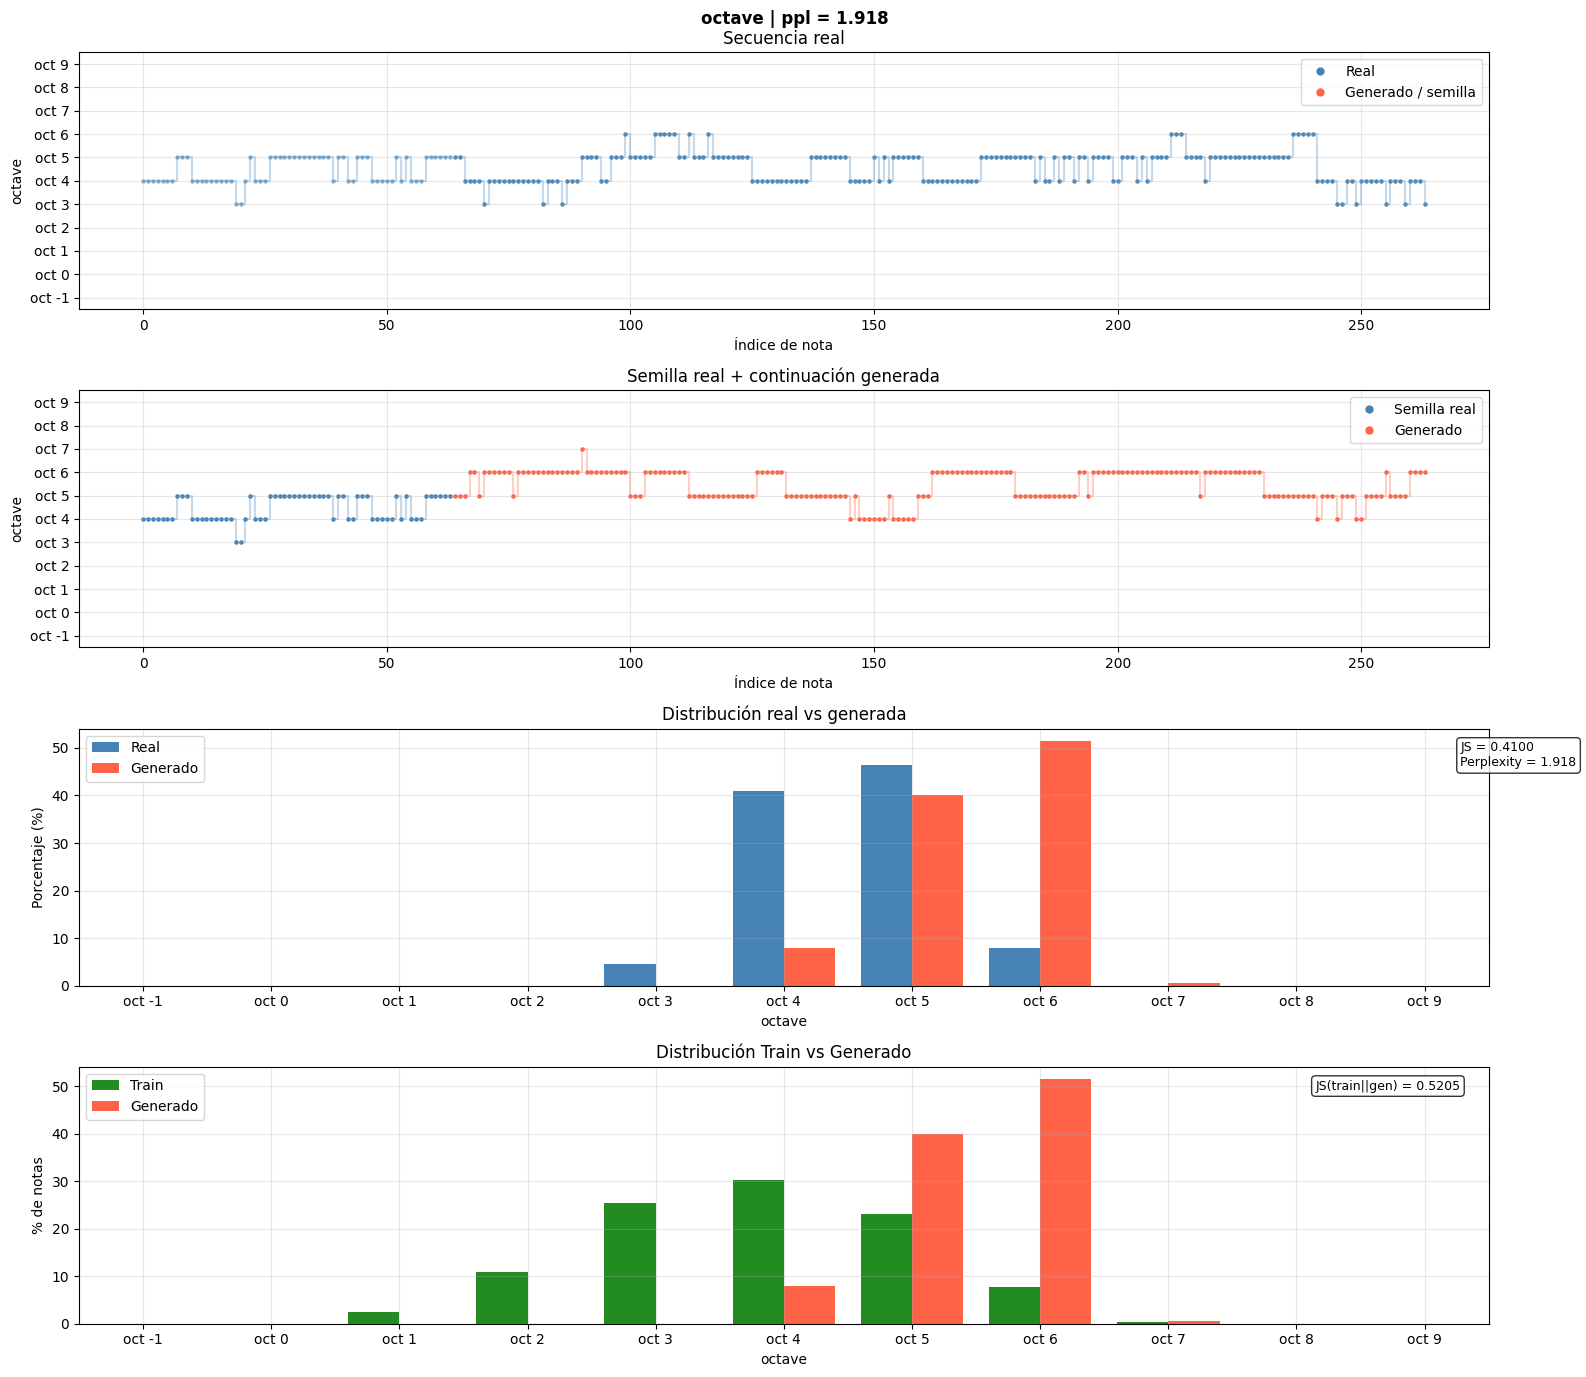

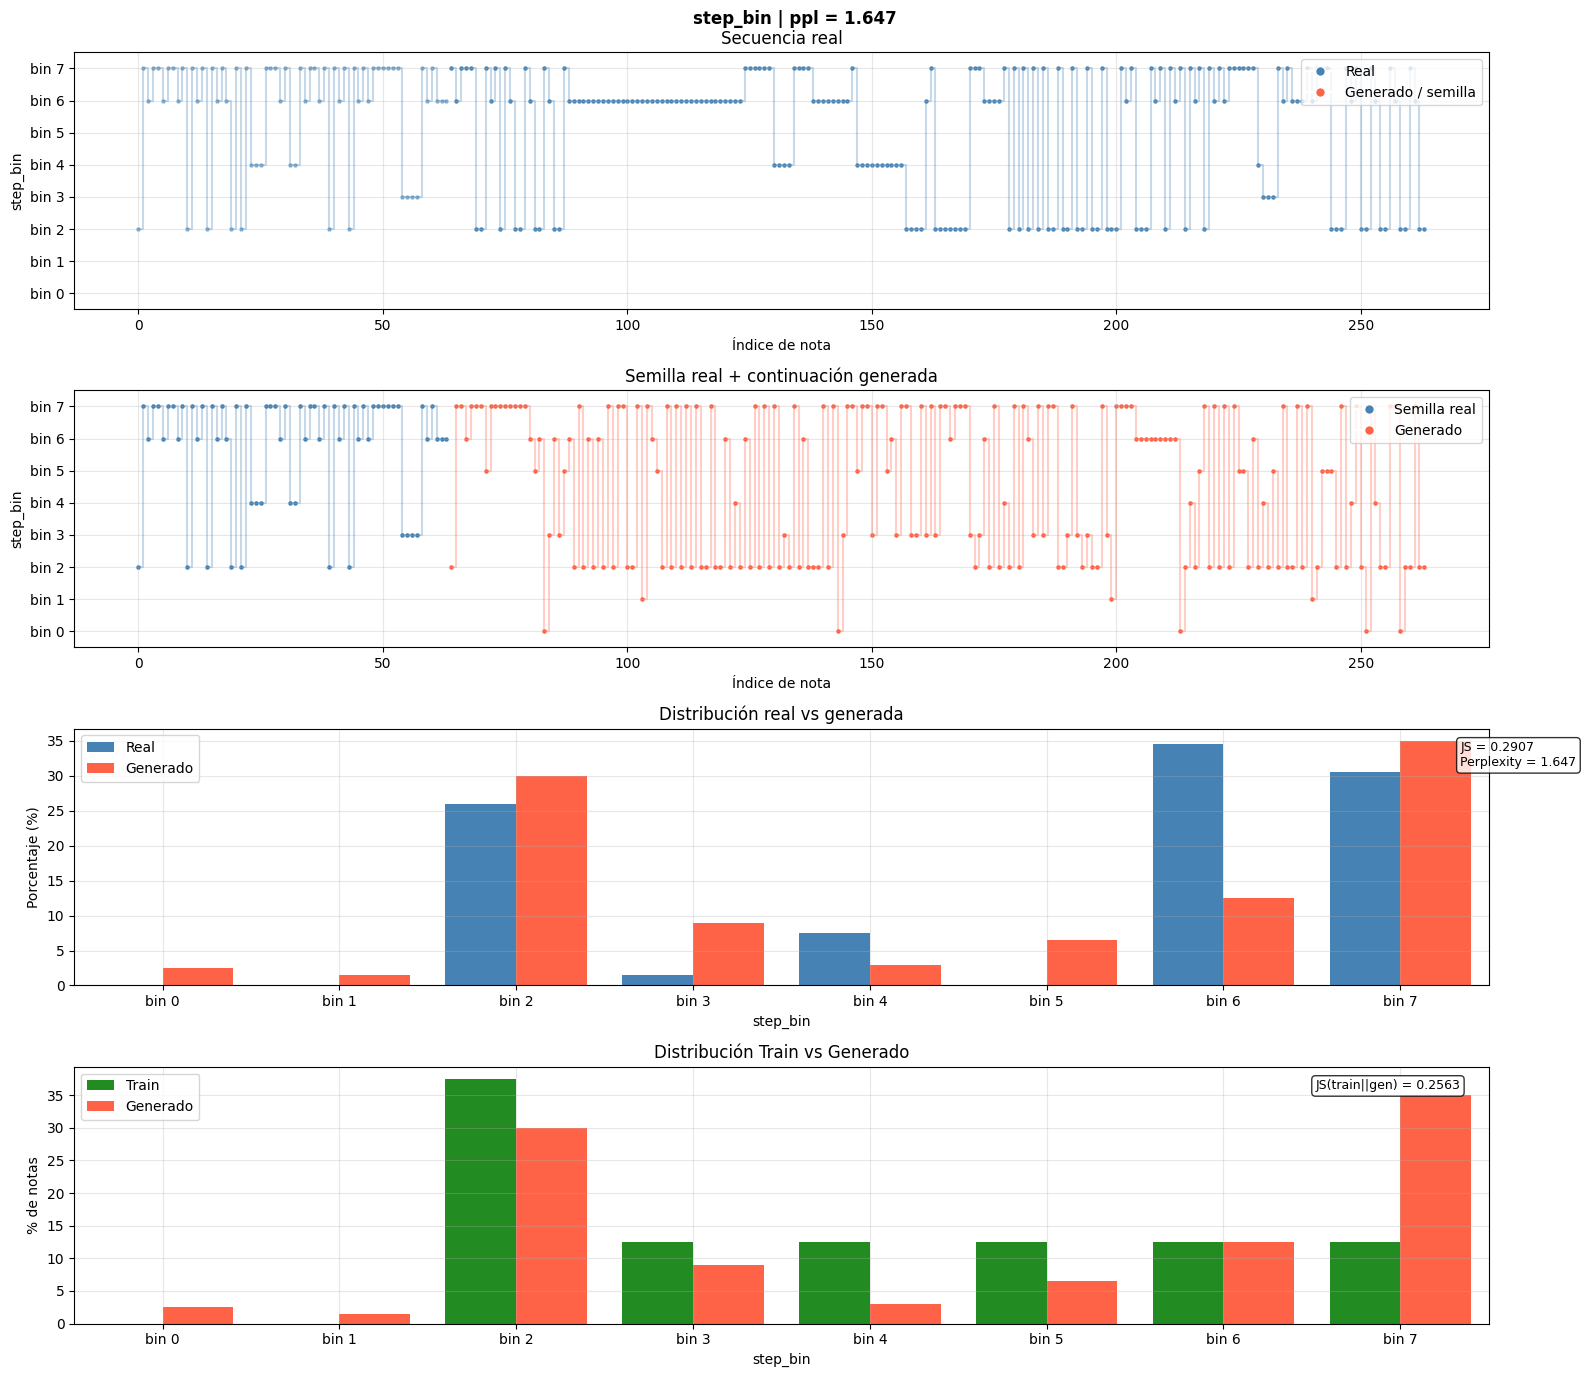

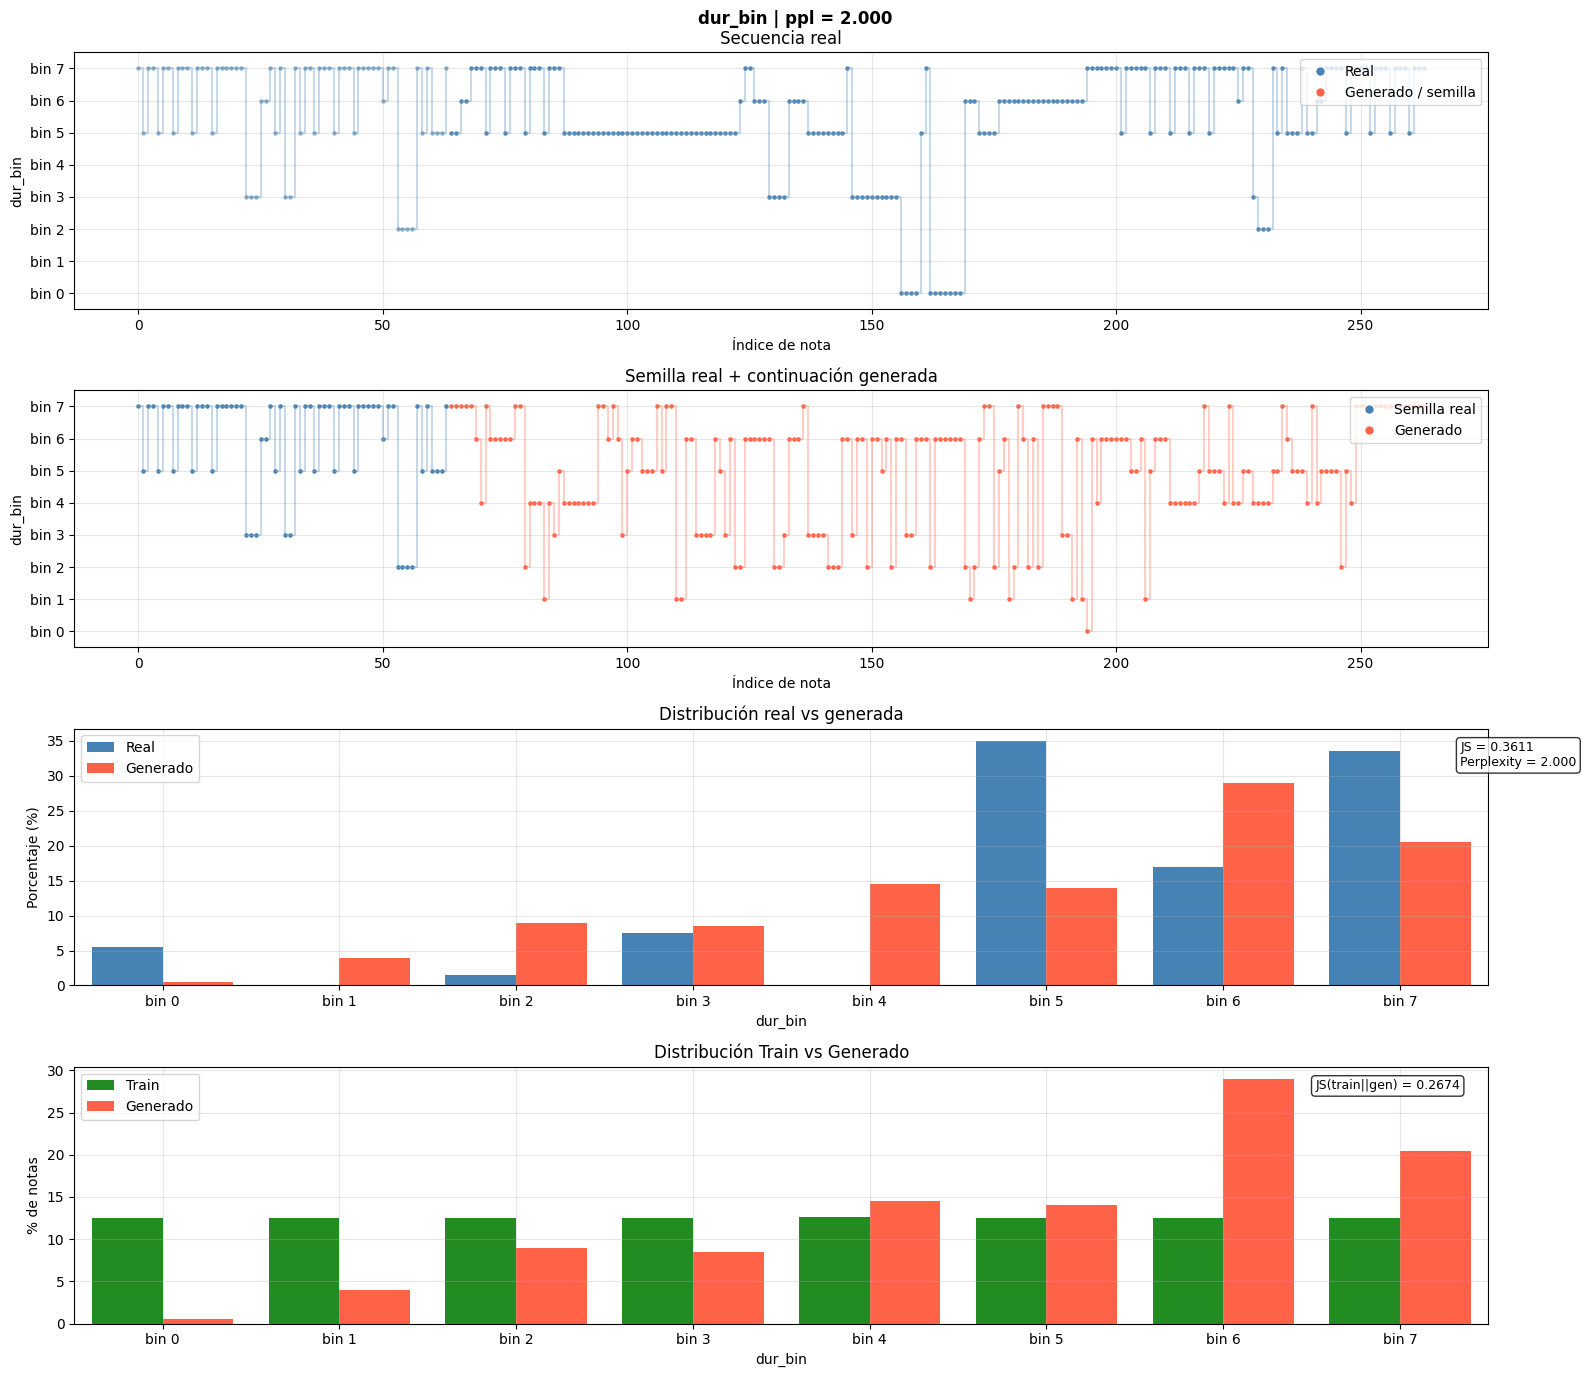

In [ ]:
for song_name, seed_beethoven in test_songs_seeds:
    print("=" * 60)
    print(f"Canción: {song_name}")
    song_df = df_test_t[df_test_t['song_name'] == song_name].reset_index(drop=True)

    gen_notes_cons = generate_with_constraints(
        net1, net2, seed_beethoven,
        interval_dist, interval_baseline,
        n_notes=200, temperature=TEMP,
        recent_window=8,        repeat_penalty=0.8,
        threshold_moderate=7,   threshold_strong=12,
        penalty_moderate=-1.0,  penalty_strong=-3.0,
        bias_strength=0.5,
    )
    compare_real_gen(gen_notes_cons, seed_beethoven, song_df)

<a id='sec11_5'></a>
## 11.5 Conclusiones — generación con restricciones musicales

El análisis de la secuencia generada con restricciones frente a la real, evaluado mediante *Perplexity* y divergencia de Jensen-Shannon (JS), muestra que el modelo mantiene un comportamiento desigual según la variable, aunque con mejoras parciales en la alineación con el estilo global al considerar *JS(train || gen)* como referencia principal. En *pitch_class*, la *Perplexity* (~5.41) sigue indicando alta dificultad, mientras que la JS (~0.10 respecto a train) mejora de forma significativa, evidenciando una mejor aproximación a la distribución tonal global, aunque aún sin capturar completamente la progresión armónica específica. En *octave*, se observa una *Perplexity* baja (~1.92), pero con una JS alta (~0.52 respecto a train), lo que indica un deterioro imptante en la distribución, mostrando que las restricciones introducen un sesgo fuerte en el rango tonal. En *step*, la *Perplexity* (~1.65) se mantiene estable y la JS (~0.26 respecto a train) refleja una modelación razonable del patrón rítmico, aunque ligeramente peor que en el baseline. En *duration*, la *Perplexity* (~2.00) se mantiene similar, pero la JS (~0.27 respecto a train) indica una desviación mayor en la distribución de duraciones, sugiriendo que las restricciones afectan negativamente esta variable. En conjunto, las restricciones musicales logran mejorar de forma clara la alineación tonal global (*pitch_class*), pero introducen distorsiones relevantes en variables como *octave* y, en menor medida, en *step* y *duration*, evidenciando un trade-off entre control musical y fidelidad estadística.

### Comparación con baseline

En comparación con el baseline, esta versión con restricciones presenta un comportamiento mixto. Por un lado, mejora de manera importante en *pitch_class* (≈0.23 → ≈0.10 en JS), lo que indica una mejor captura del estilo tonal del dataset. Sin embargo, empeora en *octave* (≈0.41 → ≈0.52), y también muestra degradaciones en *step* y *duration*, lo que sugiere que las restricciones, aunque útiles para guiar la melodía, introducen sesgos que afectan otras dimensiones musicales. La *Perplexity* se mantiene prácticamente constante en todas las variables, confirmando que los cambios observados provienen de la modificación de la distribución en inferencia y no de una mejora en la capacidad predictiva del modelo. En este sentido, aunque las restricciones aportan control y coherencia musical en ciertos aspectos, el baseline resulta más equilibrado en términos globales, mientras que la versión con restricciones favorece principalmente la estructura tonal a costa de otras propiedades musicales.

**Nota: Los valores reportados pueden variar entre ejecuciones, ya que el modelo es estocástico y genera las notas a partir de distribuciones de probabilidad. Pequeñas variaciones en una predicción inicial pueden propagarse y generar secuencias completamente diferentes, afectando tanto la secuencia generada como las métricas asociadas.**

<a id='sec12'></a>
# 12. Generación desde cero

Se generan **3 canciones completamente nuevas** sin usar ninguna canción real como semilla.
La nota inicial se deriva de la estadística de **primeras notas** del corpus de entrenamiento
(media y ±1σ por feature) y se repite `BLOCK_SIZE` veces como contexto inicial.
Se usa `generate_with_constraints` con las mismas restricciones de la sección 10.

<a id='sec12_1'></a>
## 12.1 Notas de inicio

Calcula media y desviación estándar de la primera nota de cada secuencia de entrenamiento.
Las tres semillas corresponden a: media exacta, media + 1σ y media − 1σ.

In [31]:
first_notes = np.array([seq[0] for seq in train_sequences])
mean_note   = first_notes.mean(axis=0)   # [pc, oct, step, dur]
std_note    = first_notes.std(axis=0)

lo = np.array([0,  0, 0, 0])
hi = np.array([11, 10, 7, 7])

def make_note(offset):
    return np.clip(np.round(mean_note + offset * std_note).astype(int), lo, hi).tolist()

seed_notes  = [make_note(0.0), make_note(+1.0), make_note(-1.0)]
labels      = ['media', 'media+1σ', 'media−1σ']

for label, n in zip(labels, seed_notes):
    midi = n[1] * 12 + n[0]
    print(f'{label:12s}: {pretty_midi.note_number_to_name(midi):4s} (MIDI {midi:3d})'
          f'  pc={n[0]}  oct={n[1]}  step={n[2]}  dur={n[3]}')

media       : F#3  (MIDI  54)  pc=6  oct=4  step=2  dur=5
media+1σ    : A4   (MIDI  69)  pc=9  oct=5  step=2  dur=7
media−1σ    : D2   (MIDI  38)  pc=2  oct=3  step=2  dur=3


<a id='sec12_2'></a>
## 12.2 Generación y exportación a MIDI

Cada semilla se repite `BLOCK_SIZE` veces como contexto inicial y se pasa a
`generate_with_constraints`. Las 3 canciones se guardan en `generated/`.

In [36]:
SAVE_DIR = '/content/drive/MyDrive/MASTER/Tercer_semestre/NLP_2/Microproyecto_1' if COLAB else '.'
out_dir  = os.path.join(SAVE_DIR, 'generated')
os.makedirs(out_dir, exist_ok=True)

file_labels = ['media', 'media_mas_1sigma', 'media_menos_1sigma']

for i, (start_note, label, flabel) in enumerate(zip(seed_notes, labels, file_labels)):
    gen     = generate_with_constraints(
        net1, net2, [start_note],             # semilla: una sola nota (zero-padding interno)
        interval_dist, interval_baseline,
        n_notes=200, temperature=TEMP,
        recent_window=8,        repeat_penalty=0.8,
        threshold_moderate=7,   threshold_strong=12,
        penalty_moderate=-1.0,  penalty_strong=-3.0,
        bias_strength=0.5,
    )
    decoded = decode_notes(gen, params)
    pm      = notes_to_midi(decoded, tempo_scale=1.0)
    fname   = os.path.join(out_dir, f'scratch_song_{i+1}_{flabel}.mid')
    pm.write(fname)

    midi = int(start_note[1]) * 12 + int(start_note[0])
    print(f'Song {i+1} ({label}): {pretty_midi.note_number_to_name(midi):4s} → {len(decoded)} notas → {fname}')

print('\nListo — 3 canciones guardadas en generated/')

Song 1 (media): F#3  → 200 notas → ./generated/scratch_song_1_media.mid
Song 2 (media+1σ): A4   → 200 notas → ./generated/scratch_song_2_media_mas_1sigma.mid
Song 3 (media−1σ): D2   → 200 notas → ./generated/scratch_song_3_media_menos_1sigma.mid

Listo — 3 canciones guardadas en generated/


<a id='sec13'></a>
# 13. Escuchar canciones generadas

Piano-roll y reproductor de audio para cada MIDI generado.
El reproductor usa el widget nativo de Jupyter (botón ▶/⏸ incorporado).

In [37]:
if not COLAB:
    pygame.mixer.init()
    def show_midi(path, seconds=60):
        """Piano-roll y reproducción directa del MIDI con soundfont del sistema."""
        pm    = pretty_midi.PrettyMIDI(path)
        notes = sorted(pm.instruments[0].notes, key=lambda n: n.start)
        pitches = [n.pitch for n in notes]

        # Piano-roll
        fig, ax = plt.subplots(figsize=(16, 4))
        for note in notes:
            ax.barh(note.pitch, note.end - note.start, left=note.start,
                    height=0.75, color='steelblue', alpha=0.8,
                    edgecolor='white', linewidth=0.3)
        p_lo, p_hi = min(pitches) - 1, max(pitches) + 1
        ax.set_ylim(p_lo, p_hi)
        ax.set_yticks([p for p in range(p_lo, p_hi + 1) if p % 12 == 0])
        ax.set_yticklabels([pretty_midi.note_number_to_name(p)
                            for p in range(p_lo, p_hi + 1) if p % 12 == 0], fontsize=8)
        ax.set_xlabel('Tiempo (s)')
        ax.set_ylabel('Nota')
        ax.set_title(os.path.basename(path), fontsize=12, fontweight='bold')
        ax.grid(True, axis='x', linestyle='--', alpha=0.3)
        plt.tight_layout()
        plt.show()

        duration = pm.get_end_time()
        print(f'{len(notes)} notas  |  duración: {duration:.1f}s')

        pygame.mixer.music.load(path)
        pygame.mixer.music.play()
        print(f'Reproduciendo... (Ctrl+I para interrumpir)')
        time.sleep(min(seconds, duration + 1))
        pygame.mixer.music.stop()

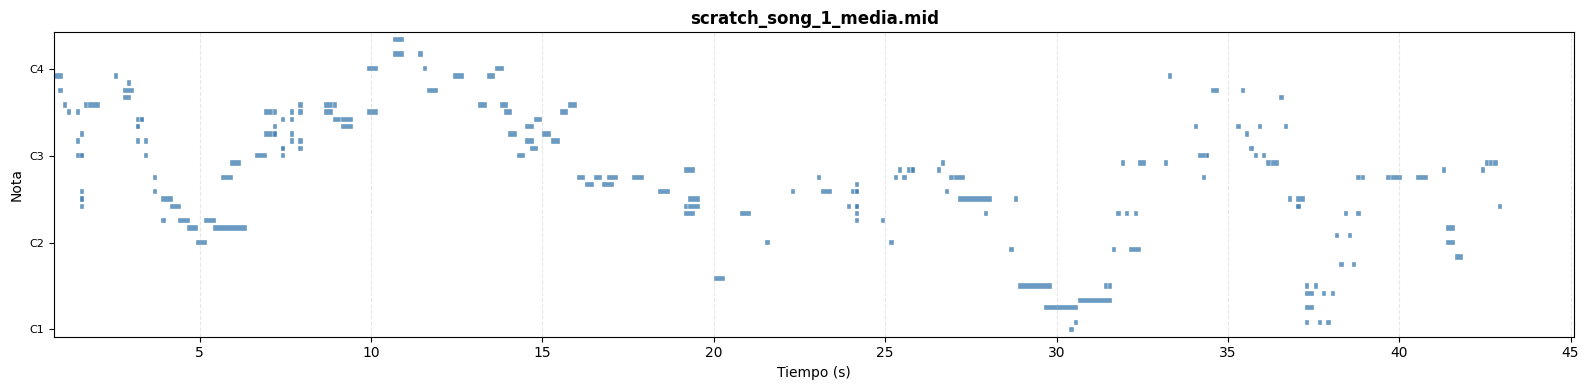

200 notas  |  duración: 43.0s
Reproduciendo... (Ctrl+I para interrumpir)


In [38]:
if not COLAB:
    show_midi(os.path.join('.', 'generated', 'scratch_song_1_media.mid'))

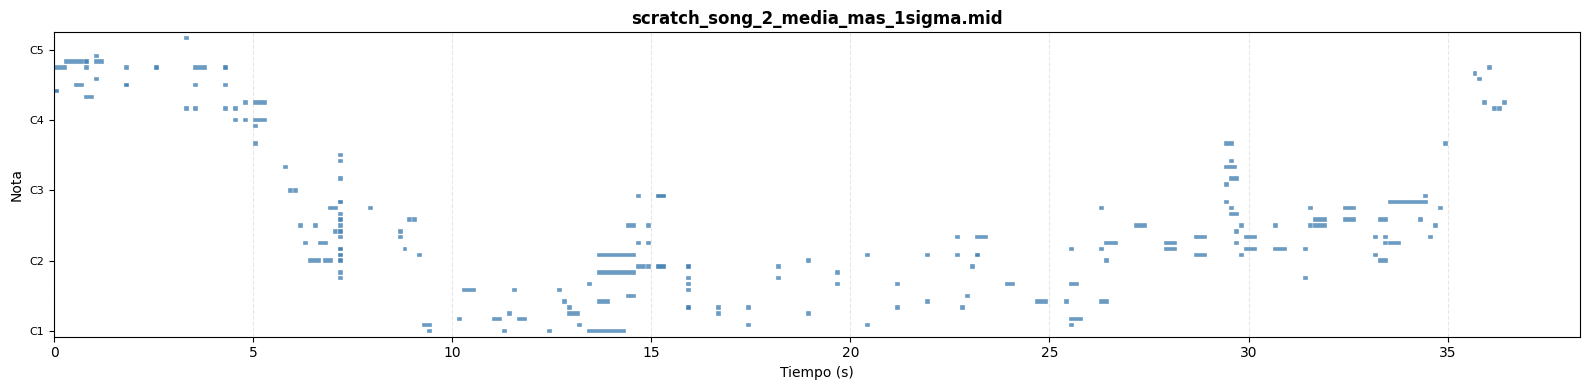

200 notas  |  duración: 36.5s
Reproduciendo... (Ctrl+I para interrumpir)


In [39]:
show_midi(os.path.join('.', 'generated', 'scratch_song_2_media_mas_1sigma.mid'))

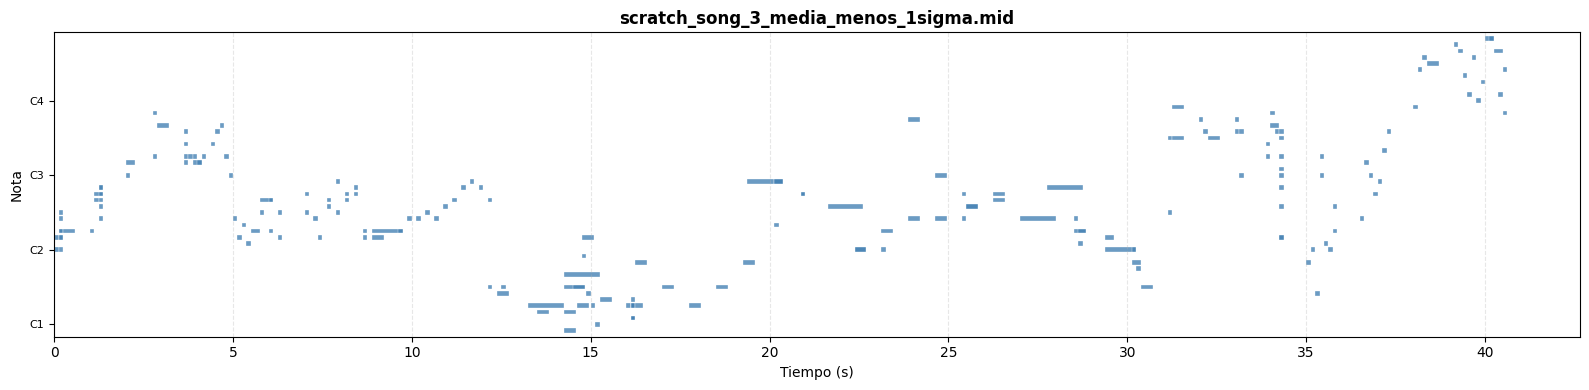

200 notas  |  duración: 40.6s
Reproduciendo... (Ctrl+I para interrumpir)


In [40]:
show_midi(os.path.join('.', 'generated', 'scratch_song_3_media_menos_1sigma.mid'))